# Modelos

Esse notebook serve para validarmos como classificadores clássicos de Machine Learning se saem ao classificar textos como scam ou não embeddados de frma inteira (a conversa inteira é representada com um único vetor)

In [3]:
import sys, os
import joblib
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

import matplotlib.pyplot as plt

sys.path.append('../')

**Dados**

Funções auxiliares para a obtenção dos dados

In [ ]:
def prepare_data(path_data, embedding, train=False, with_augmented_data=False):
    dataset_path = "train" if train else "validation"

    parquet_file = f"../datasets/dataset_{dataset_path}/processed/{path_data}/{embedding}_chunks.parquet"

    if not os.path.exists(parquet_file):
        print(f"Arquivo {parquet_file} não encontrado. Pulando...")
        return
    
    print(f"Carregando dados de {parquet_file}...")

    df = pd.read_parquet(parquet_file)

    if not with_augmented_data:
        df = df[df['origin'] == 'external']

    X_train, X_val, y_train, y_val = train_test_split(
        list(df['text_embedded']),
        list(df['label']),
        test_size=0.2,
        random_state=42,
        stratify=df['label']
    )

    print(f"Dados carregados. Total de amostras: {len(df)}. 80% para treinamento, 20% para validação.")
    return X_train, X_val, y_train, y_val

**Treinamento**

Os modelos são setados em outro documento, aqui apenas realizamos o treinamento deles.

Não realizamos a divisão de treino, validação e teste de forma explícita por estamos fazendo um K-fold, com k=5, o que dividiria nosso dataset em 64% treino, 16% valdiação e 20% teste.

In [5]:
from machine_learning.classifier import get_all_classifiers
from config import EMBEDDERS

MODELS_DIR = "trained_models"

models = get_all_classifiers()

def evaluate_model(model, X_val, y_val):
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1_macro = f1_score(y_val, y_val_pred, average='macro')

    print(f"      Acurácia na validação: {val_accuracy:.4f} | F1-macro na validação: {val_f1_macro:.4f}")

    return val_accuracy, val_f1_macro

def train_model(model, embedding, with_augmented_data=True, path_data='all_data'):
    print(f"Iniciando o treinamento do modelo {type(model).__name__}...")

    X_train, X_val, y_train, y_val = prepare_data(path_data, embedding, train=True, with_augmented_data=with_augmented_data)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    print(f"      F1-macro médio (5-fold CV) - treino: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

    model.fit(X_train, y_train)

    val_accuracy, val_f1_macro = evaluate_model(model, X_val, y_val)

    origin_text = 'augmented' if with_augmented_data else 'external_only'

    model_filename = f"{origin_text}_{path_data}_{embedding}_{type(model).__name__}.joblib"
    
    model_path = f"../{MODELS_DIR}/{model_filename}"
    joblib.dump(model, model_path)
    print(f"      Modelo salvo em: {model_path}")

    return val_accuracy, val_f1_macro


def train_all_models(with_augmented_data=True, path_data='all_data'):
    print("Iniciando o treinamento de todos os modelos...\n")

    final_stats = {}
    for emb_name, emb_func in EMBEDDERS.items():
        for alg_name, model in models.items():
            try:
                print(f"\nTreinando modelo: {alg_name.upper()} | Embedding: {emb_name}")
                accuracy, f1_macro = train_model(model, emb_name, with_augmented_data, path_data)
                final_stats[(emb_name, alg_name)] = (accuracy, f1_macro)
            except Exception as e:
                print(f"Erro ao treinar modelo {alg_name.upper()} para o dataset de treino com embedding {emb_name}: {e}")

    print("\nTreinamento concluído!")
    return final_stats


Aviso: length_data não fornecido para RF. Usando n_estimators=100 por padrão.
Aviso: length_data não fornecido para XGBOOST. Usando n_estimators=100 por padrão.


**Treino**

Treinamos 5 modelos em 4 cenários diferentes:
- Com ou sem data augmentation e vendo todos os turnos ou apenas os turnos do suspeito de scam

In [3]:
print("************************ Treinando modelos sem dados aumentados para o dataset completo... ************************")

stats_without_augmented_data = train_all_models(with_augmented_data=False, path_data='all_data')


************************ Treinando modelos sem dados aumentados para o dataset completo... ************************
Iniciando o treinamento de todos os modelos...


Treinando modelo: RF | Embedding: minilm
Iniciando o treinamento do modelo RandomForestClassifier...
Carregando dados de ../datasets/dataset_train/processed/all_data/minilm_chunks.parquet...
Dados carregados. Total de amostras: 6822. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9521 (+/- 0.0091)
      Acurácia na validação: 0.9458 | F1-macro na validação: 0.9455
      Modelo salvo em: ../trained_models/external_only_all_data_minilm_RandomForestClassifier.joblib

Treinando modelo: KNN | Embedding: minilm
Iniciando o treinamento do modelo KNeighborsClassifier...
Carregando dados de ../datasets/dataset_train/processed/all_data/minilm_chunks.parquet...
Dados carregados. Total de amostras: 6822. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9484 (

In [47]:
print("************************ Treinando modelos com dados aumentados para o dataset completo... ************************")

stats_with_augmented_data = train_all_models(with_augmented_data=True, path_data='all_data')

************************ Treinando modelos com dados aumentados para o dataset completo... ************************
Iniciando o treinamento de todos os modelos...


Treinando modelo: RF | Embedding: voyage
Iniciando o treinamento do modelo RandomForestClassifier...
Carregando dados de ../datasets/dataset_train/processed/all_data/voyage_chunks.parquet...
Dados carregados. Total de amostras: 9648. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9700 (+/- 0.0156)
      Acurácia na validação: 0.9674 | F1-macro na validação: 0.9629
      Modelo salvo em: ../trained_models/augmented_all_data_voyage_RandomForestClassifier.joblib

Treinando modelo: KNN | Embedding: voyage
Iniciando o treinamento do modelo KNeighborsClassifier...
Carregando dados de ../datasets/dataset_train/processed/all_data/voyage_chunks.parquet...
Dados carregados. Total de amostras: 9648. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9709 (+/- 

KeyboardInterrupt: 

In [5]:
print("************************ Treinando modelos sem dados aumentados para o dataset apenas com suspect... ************************")

stats_without_augmented_suspect = train_all_models(with_augmented_data=False, path_data='suspect_turns')

************************ Treinando modelos sem dados aumentados para o dataset apenas com suspect... ************************
Iniciando o treinamento de todos os modelos...


Treinando modelo: RF | Embedding: minilm
Iniciando o treinamento do modelo RandomForestClassifier...
Carregando dados de ../datasets/dataset_train/processed/suspect_turns/minilm_chunks.parquet...
Dados carregados. Total de amostras: 6822. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9468 (+/- 0.0096)
      Acurácia na validação: 0.9436 | F1-macro na validação: 0.9433
      Modelo salvo em: ../trained_models/external_only_suspect_turns_minilm_RandomForestClassifier.joblib

Treinando modelo: KNN | Embedding: minilm
Iniciando o treinamento do modelo KNeighborsClassifier...
Carregando dados de ../datasets/dataset_train/processed/suspect_turns/minilm_chunks.parquet...
Dados carregados. Total de amostras: 6822. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fo

In [6]:
print("************************ Treinando modelos com dados aumentados para o dataset apenas com suspect... ************************")

stats_with_augmented_suspect = train_all_models(with_augmented_data=True, path_data='suspect_turns')

************************ Treinando modelos com dados aumentados para o dataset apenas com suspect... ************************
Iniciando o treinamento de todos os modelos...


Treinando modelo: RF | Embedding: minilm
Iniciando o treinamento do modelo RandomForestClassifier...
Carregando dados de ../datasets/dataset_train/processed/suspect_turns/minilm_chunks.parquet...
Dados carregados. Total de amostras: 9648. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold CV) - treino: 0.9565 (+/- 0.0150)
      Acurácia na validação: 0.9513 | F1-macro na validação: 0.9443
      Modelo salvo em: ../trained_models/augmented_suspect_turns_minilm_RandomForestClassifier.joblib

Treinando modelo: KNN | Embedding: minilm
Iniciando o treinamento do modelo KNeighborsClassifier...
Carregando dados de ../datasets/dataset_train/processed/suspect_turns/minilm_chunks.parquet...
Dados carregados. Total de amostras: 9648. 80% para treinamento, 20% para validação.
      F1-macro médio (5-fold C

**Resultados**

Principais resultados dos 20% de teste do treino

## Top 5 melhores matrizes de confusão por tipo de treino

### augmented_all_data

,label,accuracy,f1_macro,tp,tn,fp_total,fn_total
0,augmented_all_data_voyage_SVC,0.975,0.972,1261,621,25,23
1,augmented_all_data_openai_SVC,0.974,0.970,1261,618,28,23
2,augmented_all_data_openai_RandomForestClassifier,0.970,0.966,1275,598,48,9
3,augmented_all_data_openai_KNeighborsClassifier,0.969,0.966,1254,617,29,30
4,augmented_all_data_bge_SVC,0.968,0.964,1262,606,40,22


**Matriz de confusão: augmented_all_data_voyage_SVC**

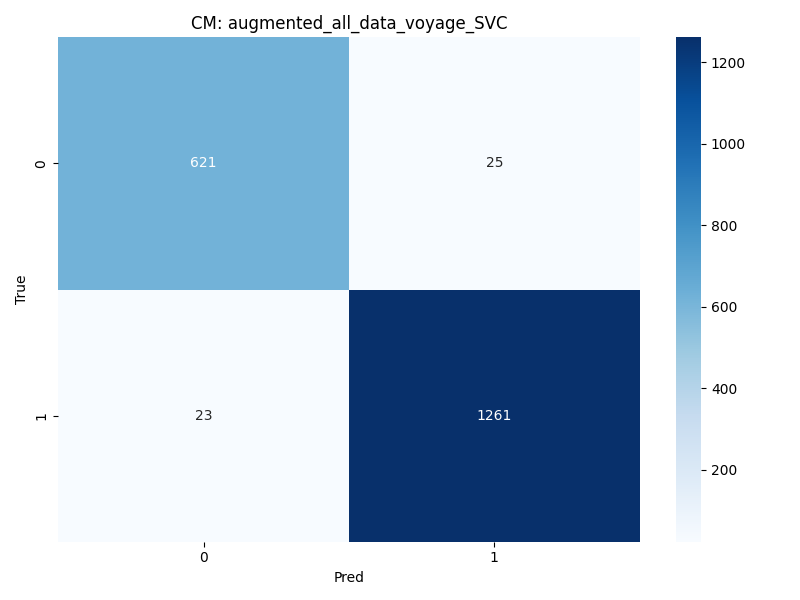

**Matriz de confusão: augmented_all_data_openai_SVC**

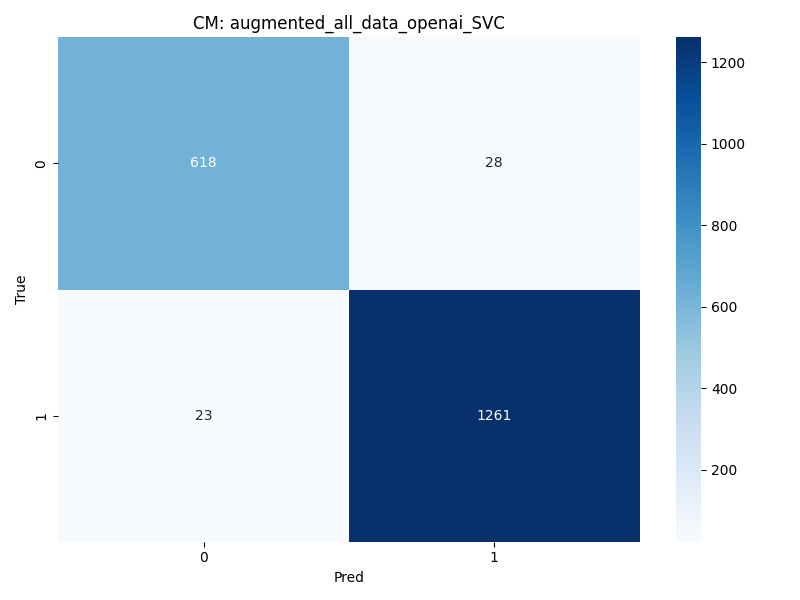

**Matriz de confusão: augmented_all_data_openai_RandomForestClassifier**

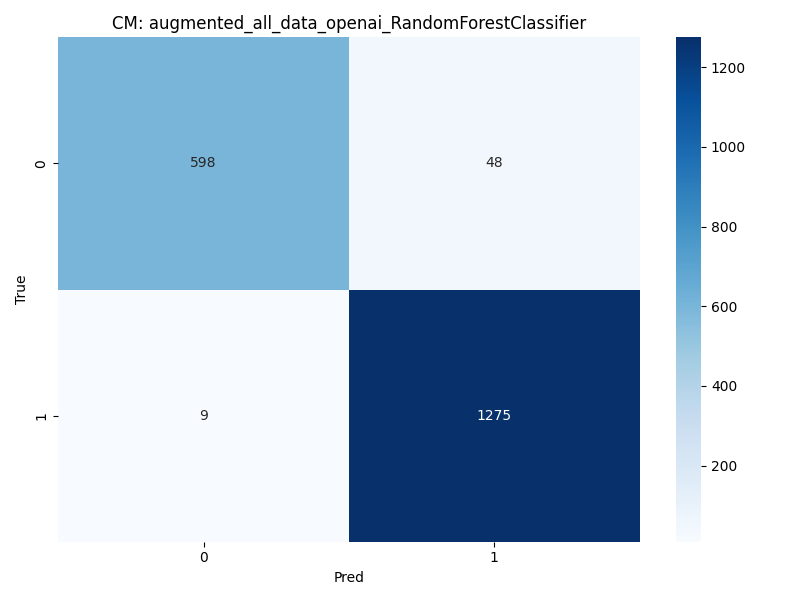

**Matriz de confusão: augmented_all_data_openai_KNeighborsClassifier**

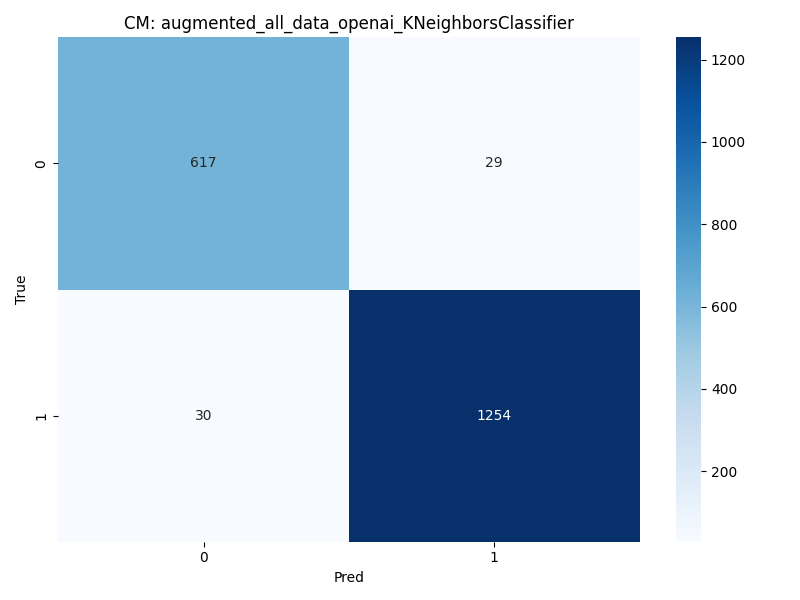

**Matriz de confusão: augmented_all_data_bge_SVC**

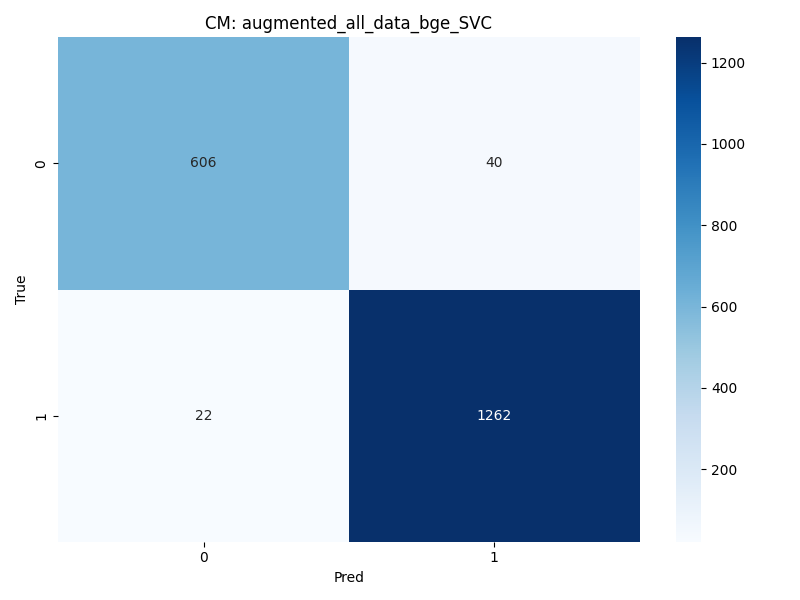

### external_only_all_data

,label,accuracy,f1_macro,tp,tn,fp_total,fn_total
0,external_only_all_data_voyage_SVC,0.966,0.966,697,622,24,22
1,external_only_all_data_openai_SVC,0.966,0.966,699,620,26,20
2,external_only_all_data_voyage_KNeighborsClassi...,0.958,0.958,683,625,21,36
3,external_only_all_data_openai_RandomForestClas...,0.958,0.958,701,607,39,18
4,external_only_all_data_openai_KNeighborsClassi...,0.958,0.957,689,618,28,30


**Matriz de confusão: external_only_all_data_voyage_SVC**

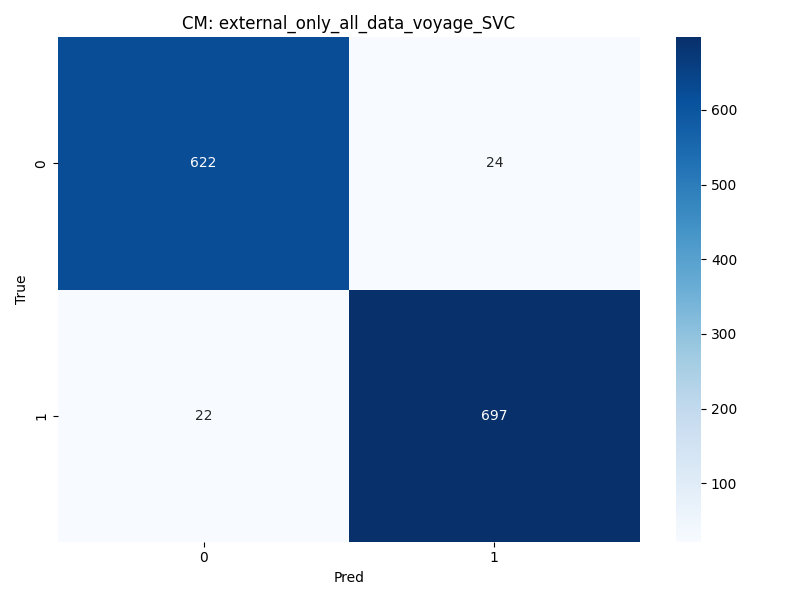

**Matriz de confusão: external_only_all_data_openai_SVC**

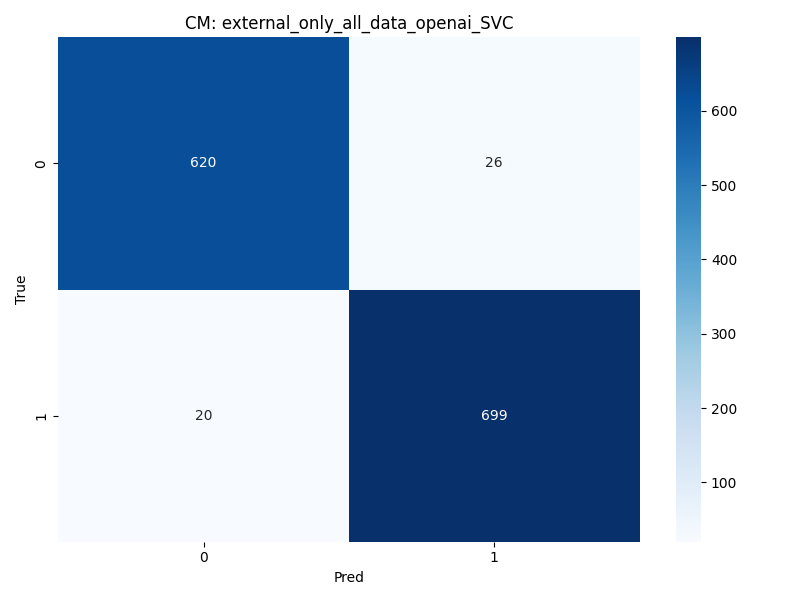

**Matriz de confusão: external_only_all_data_voyage_KNeighborsClassifier**

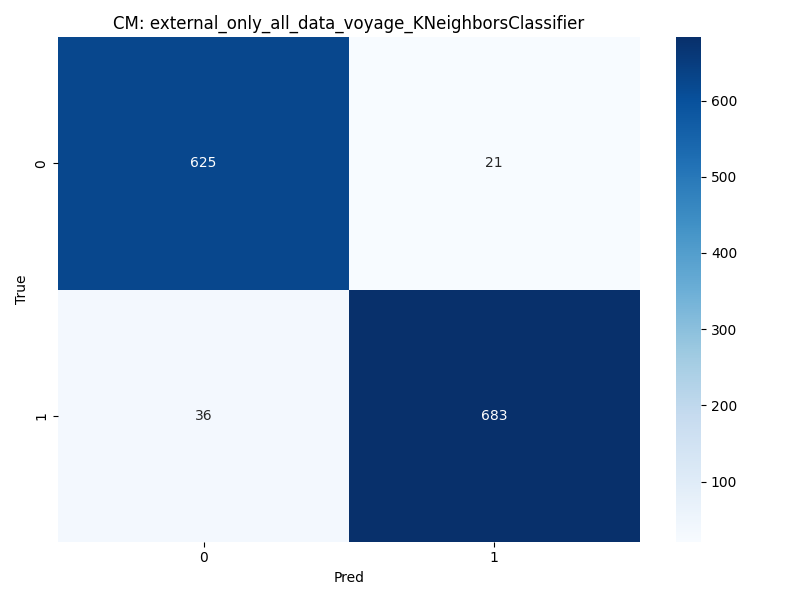

**Matriz de confusão: external_only_all_data_openai_RandomForestClassifier**

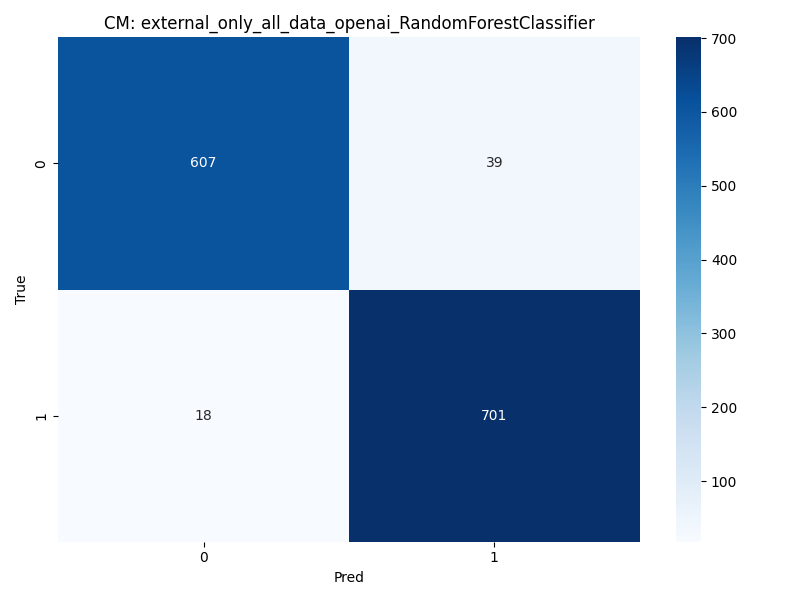

**Matriz de confusão: external_only_all_data_openai_KNeighborsClassifier**

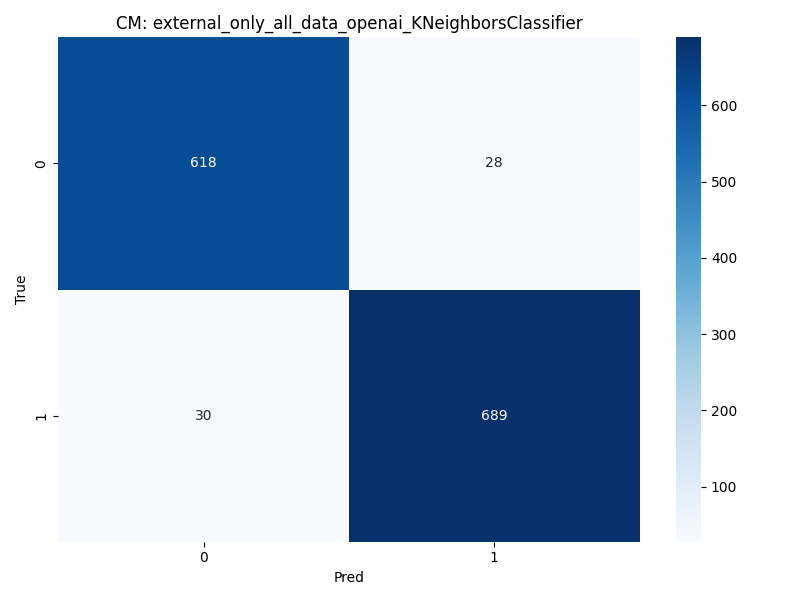

### augmented_suspect_turns

,label,accuracy,f1_macro,tp,tn,fp_total,fn_total
0,augmented_suspect_turns_openai_SVC,0.973,0.968,1105,462,24,19
1,augmented_suspect_turns_voyage_SVC,0.972,0.967,1102,463,23,22
2,augmented_suspect_turns_openai_RandomForestCla...,0.963,0.955,1110,440,46,14
3,augmented_suspect_turns_voyage_KNeighborsClass...,0.961,0.954,1085,462,24,39
4,augmented_suspect_turns_voyage_RandomForestCla...,0.961,0.952,1112,435,51,12


**Matriz de confusão: augmented_suspect_turns_openai_SVC**

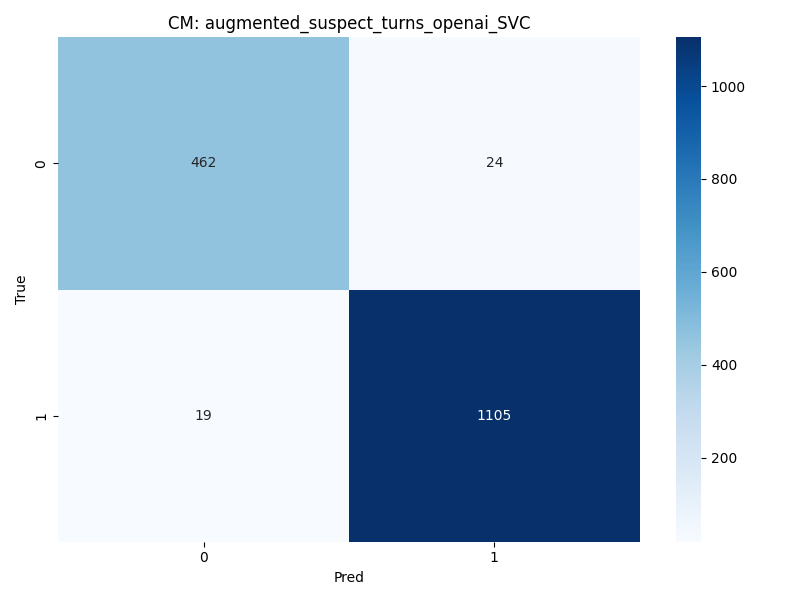

**Matriz de confusão: augmented_suspect_turns_voyage_SVC**

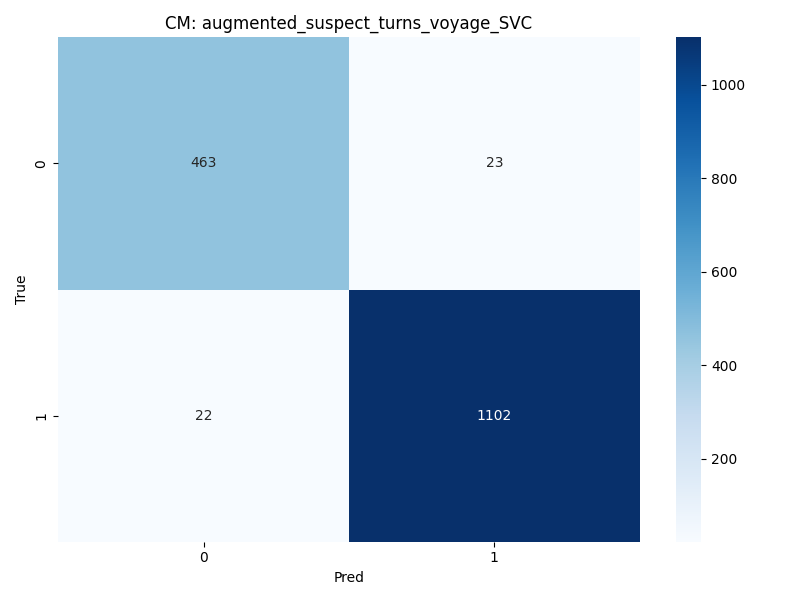

**Matriz de confusão: augmented_suspect_turns_openai_RandomForestClassifier**

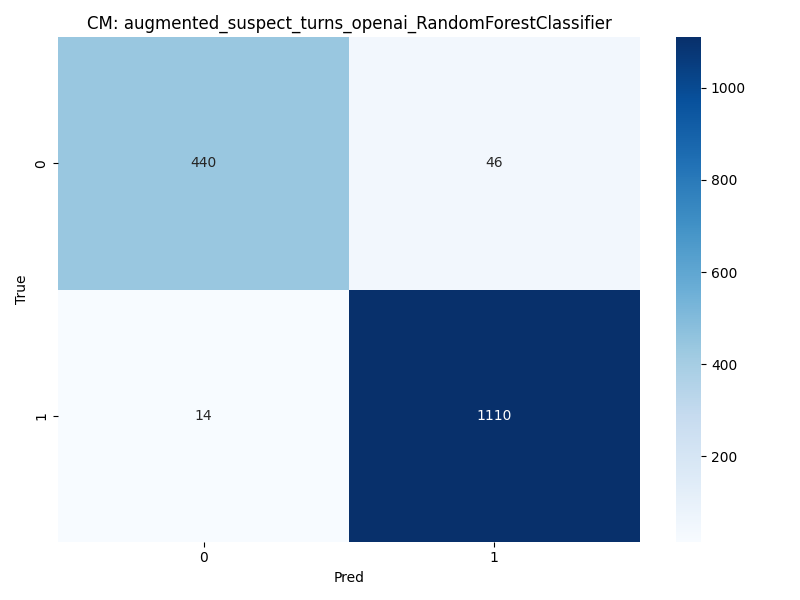

**Matriz de confusão: augmented_suspect_turns_voyage_KNeighborsClassifier**

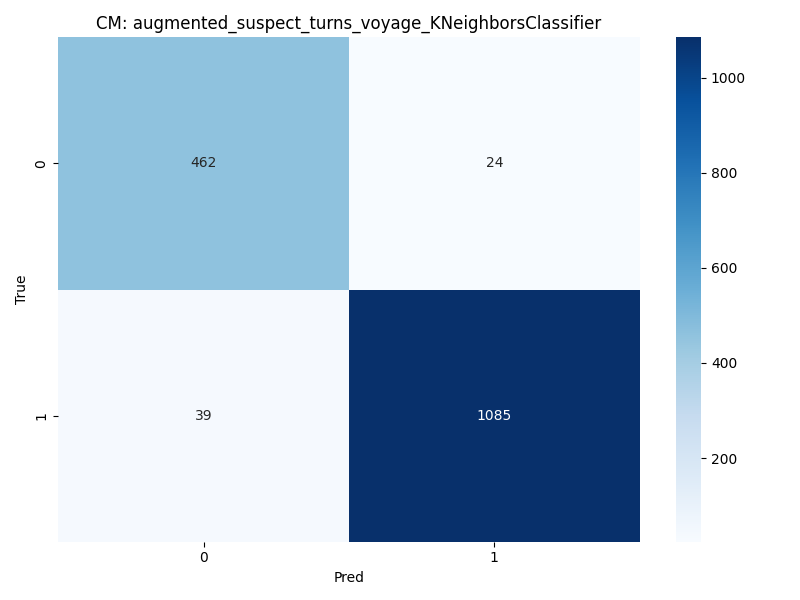

**Matriz de confusão: augmented_suspect_turns_voyage_RandomForestClassifier**

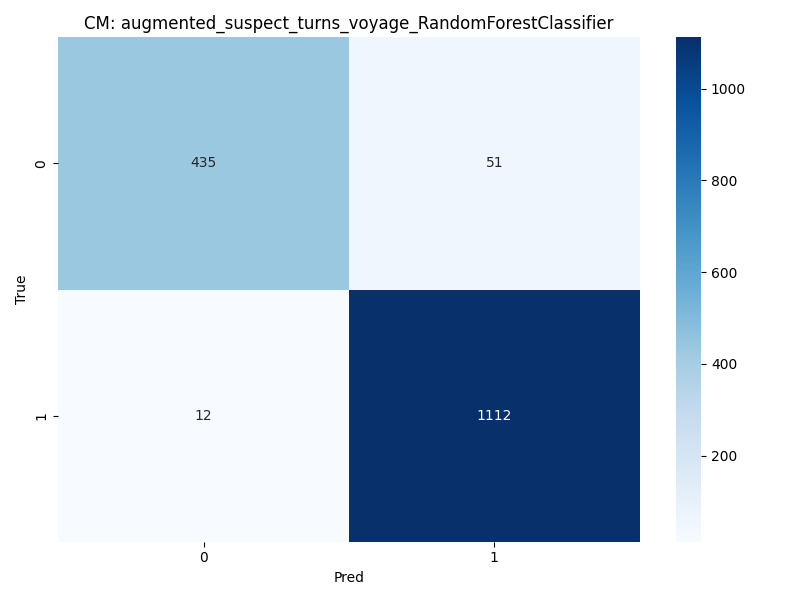

### external_only_suspect_turns

,label,accuracy,f1_macro,tp,tn,fp_total,fn_total
0,external_only_suspect_turns_voyage_SVC,0.967,0.966,545,465,21,14
1,external_only_suspect_turns_openai_SVC,0.964,0.963,544,463,23,15
2,external_only_suspect_turns_voyage_KNeighborsC...,0.956,0.956,537,462,24,22
3,external_only_suspect_turns_voyage_RandomFores...,0.954,0.954,548,449,37,11
4,external_only_suspect_turns_bge_SVC,0.947,0.947,539,451,35,20


**Matriz de confusão: external_only_suspect_turns_voyage_SVC**

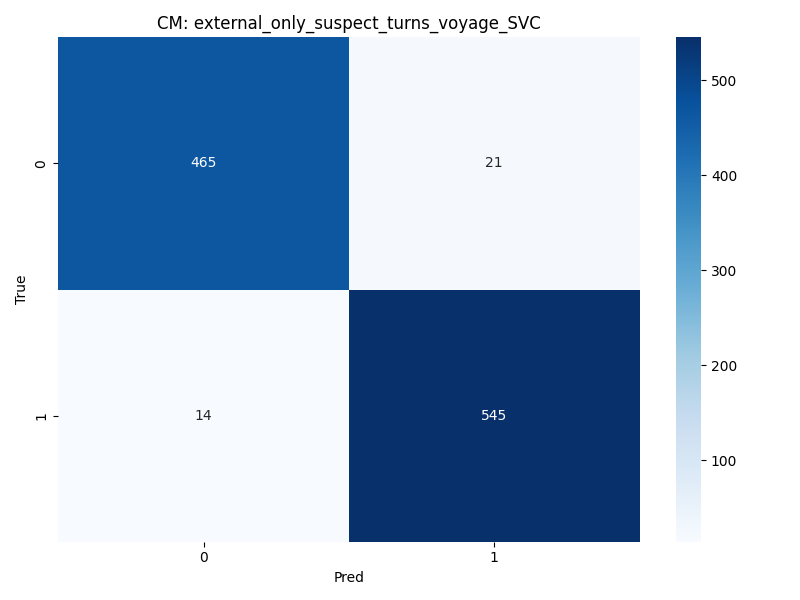

**Matriz de confusão: external_only_suspect_turns_openai_SVC**

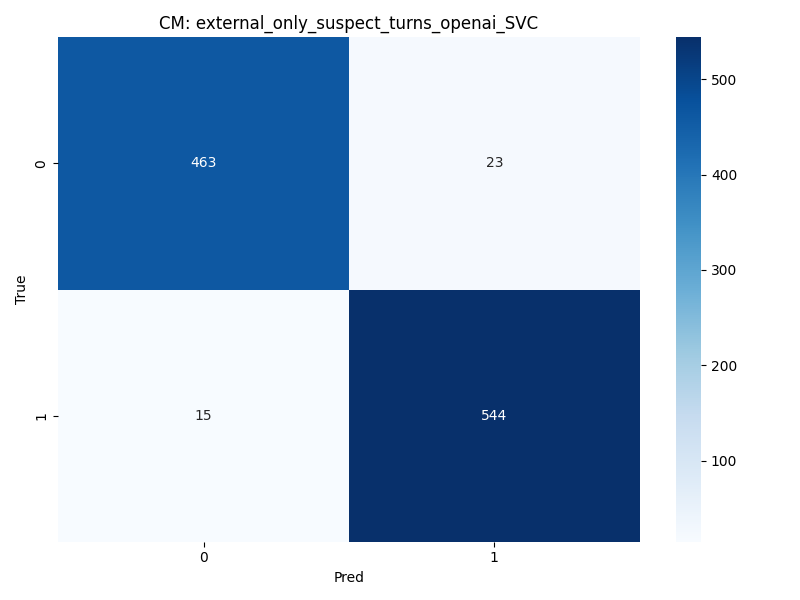

**Matriz de confusão: external_only_suspect_turns_voyage_KNeighborsClassifier**

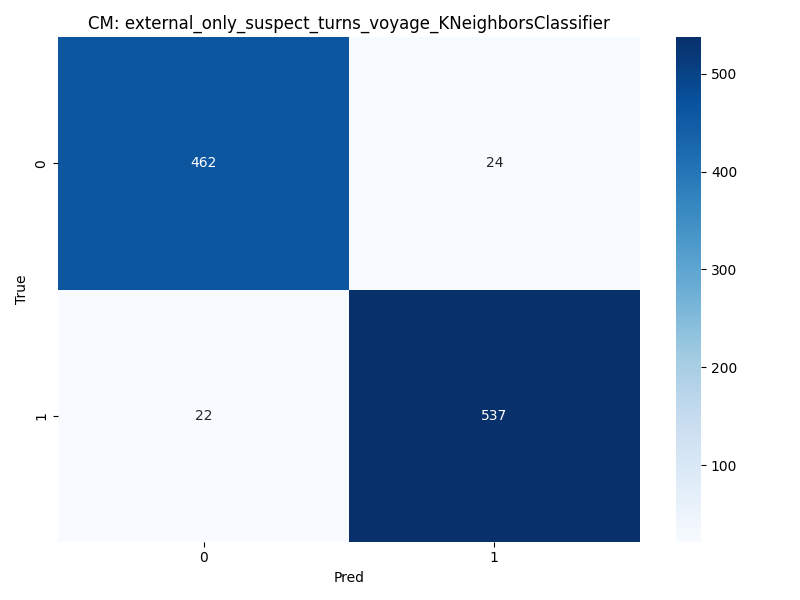

**Matriz de confusão: external_only_suspect_turns_voyage_RandomForestClassifier**

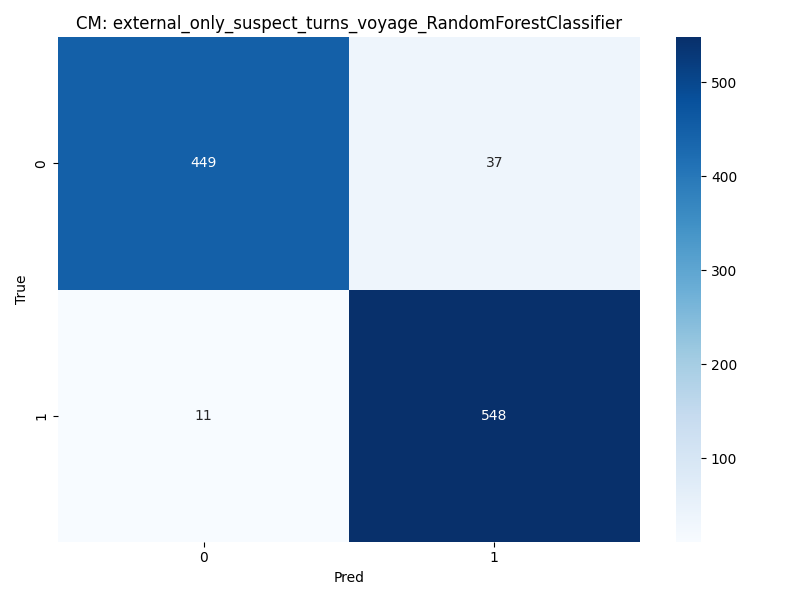

**Matriz de confusão: external_only_suspect_turns_bge_SVC**

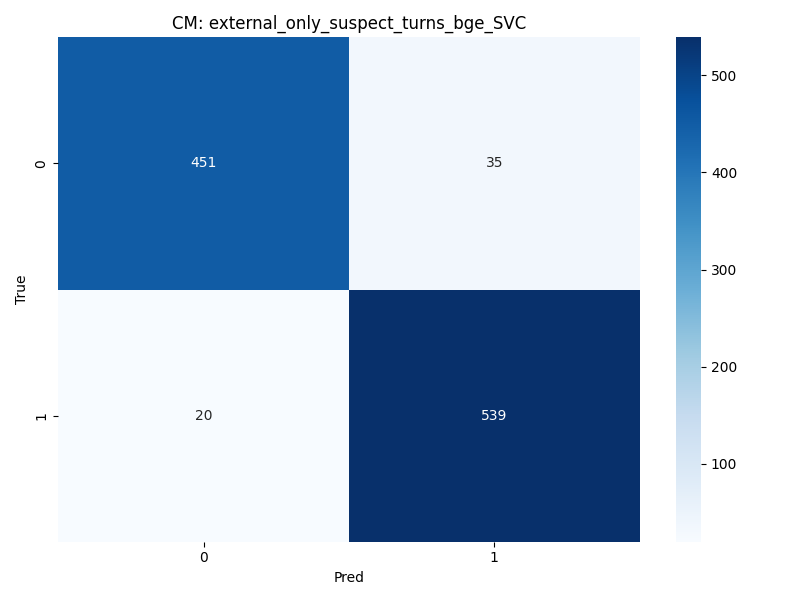

In [7]:
from IPython.display import Image, Markdown, display
import os
import pandas as pd
import sys

sys.path.append('..')
from machine_learning.visualize_results import main as visualize_main

OUT_DIR = os.path.join('..', 'machine_learning', 'visualizations')
summary_csv = os.path.join(OUT_DIR, 'models_metrics_summary.csv')
if not os.path.exists(summary_csv):
    print(f'Não encontrei o resumo em {summary_csv}. Gerando métricas e matrizes de confusão...')
    visualize_main(out_dir=OUT_DIR)
    if not os.path.exists(summary_csv):
        raise FileNotFoundError(f'Resumo não encontrado em: {summary_csv}')

metrics = pd.read_csv(summary_csv)
metrics = metrics.sort_values(['train_type', 'fp_fn_sum', 'fp_total', 'fn_total'])

display(Markdown('## Top 5 melhores matrizes de confusão por tipo de treino'))

train_types = ['augmented_all_data', 'external_only_all_data', 'augmented_suspect_turns', 'external_only_suspect_turns']

for train_type in train_types:
    subset = metrics[metrics['train_type'] == train_type].head(5)
    if subset.empty:
        display(Markdown(f'### {train_type} — sem resultados'))
        continue

    display(Markdown(f'### {train_type}'))
    display(
        subset[['label', 'accuracy', 'f1_macro', 'tp', 'tn', 'fp_total', 'fn_total']]
        .round({'accuracy': 3, 'f1_macro': 3})
        .reset_index(drop=True)
    )

    for label in subset['label'].tolist():
        img_path = os.path.join(OUT_DIR, f'cm_{label}.png')
        if os.path.exists(img_path):
            display(Markdown(f'**Matriz de confusão: {label}**'))
            display(Image(img_path, width=700))
        else:
            print('Imagem não encontrada:', img_path)


## Desempenho com o dataset de validação

## Validação — augmented_all_data (Top 5)

,label,accuracy,f1_macro,fp_total,fn_total,fp_fn_sum
23,augmented_all_data_voyage_SVC,0.975,0.972,25,23,48
18,augmented_all_data_openai_SVC,0.974,0.970,28,23,51
17,augmented_all_data_openai_RandomForestClassifier,0.970,0.966,48,9,57
15,augmented_all_data_openai_KNeighborsClassifier,0.969,0.966,29,30,59
3,augmented_all_data_bge_SVC,0.968,0.964,40,22,62


### Validando: augmented_all_data_voyage_SVC

- Acurácia (val): **0.9935** | F1-macro (val): **0.9762** | FP: **0** | FN: **7**

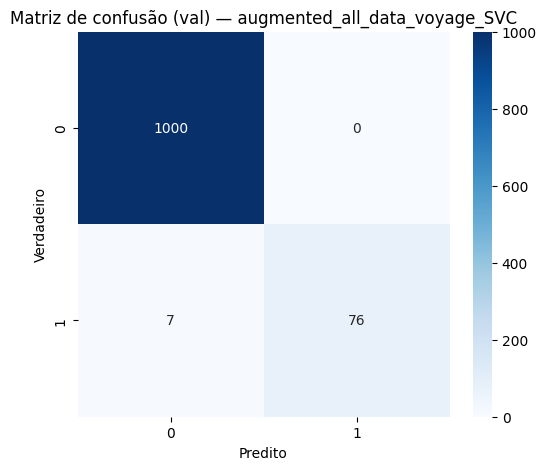

### Validando: augmented_all_data_openai_SVC

- Acurácia (val): **0.9603** | F1-macro (val): **0.8147** | FP: **0** | FN: **43**

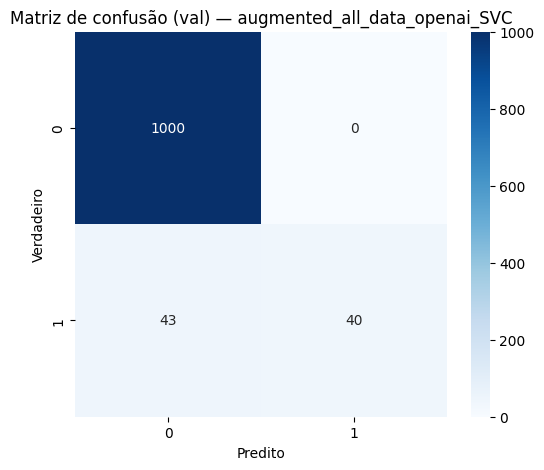

### Validando: augmented_all_data_openai_RandomForestClassifier

- Acurácia (val): **0.9880** | F1-macro (val): **0.9548** | FP: **1** | FN: **12**

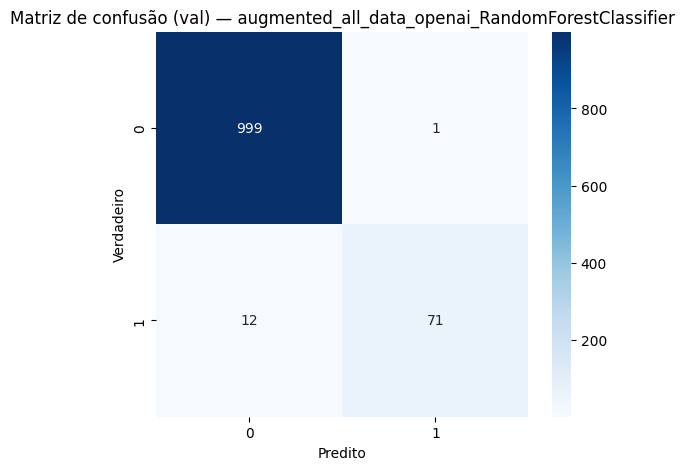

### Validando: augmented_all_data_openai_KNeighborsClassifier

- Acurácia (val): **0.9751** | F1-macro (val): **0.8962** | FP: **0** | FN: **27**

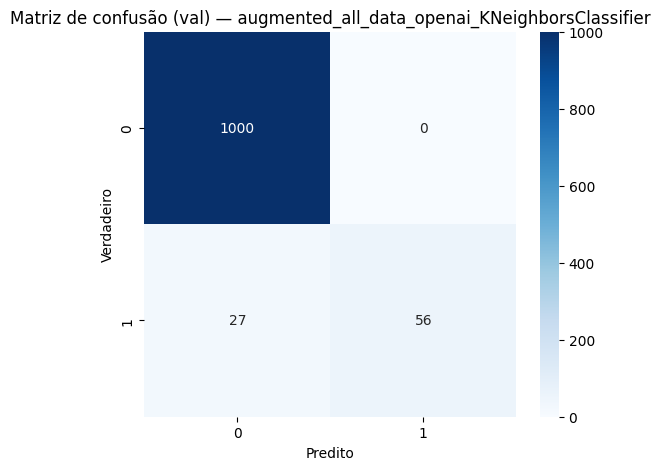

### Validando: augmented_all_data_bge_SVC

- Acurácia (val): **0.9151** | F1-macro (val): **0.6065** | FP: **25** | FN: **67**

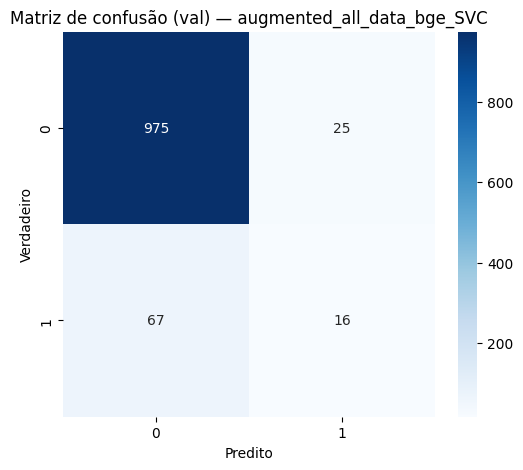

## Validação — external_only_all_data (Top 5)

,label,accuracy,f1_macro,fp_total,fn_total,fp_fn_sum
73,external_only_all_data_voyage_SVC,0.966,0.966,24,22,46
68,external_only_all_data_openai_SVC,0.966,0.966,26,20,46
70,external_only_all_data_voyage_KNeighborsClassi...,0.958,0.958,21,36,57
67,external_only_all_data_openai_RandomForestClas...,0.958,0.958,39,18,57
65,external_only_all_data_openai_KNeighborsClassi...,0.958,0.957,28,30,58


### Validando: external_only_all_data_voyage_SVC

- Acurácia (val): **0.9935** | F1-macro (val): **0.9762** | FP: **0** | FN: **7**

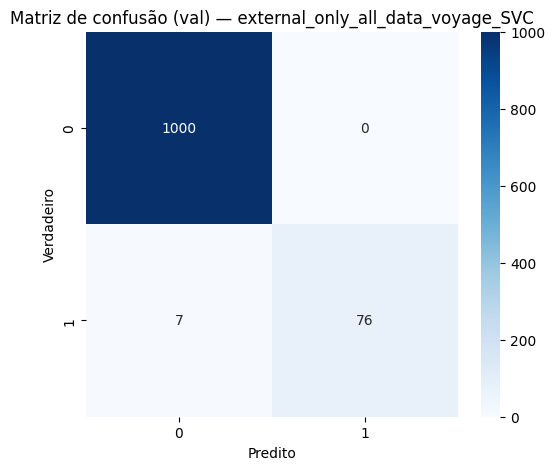

### Validando: external_only_all_data_openai_SVC

- Acurácia (val): **0.9695** | F1-macro (val): **0.8678** | FP: **0** | FN: **33**

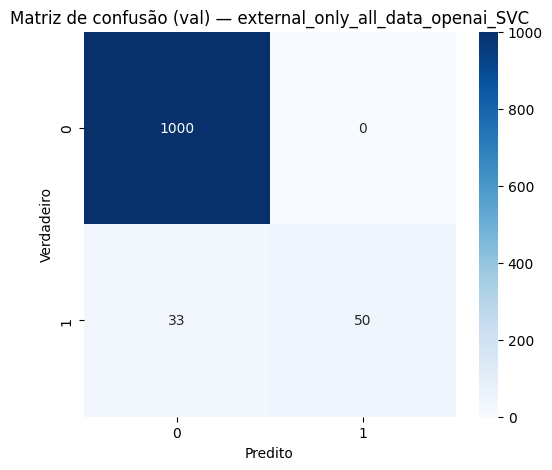

### Validando: external_only_all_data_voyage_KNeighborsClassifier

- Acurácia (val): **0.9584** | F1-macro (val): **0.8030** | FP: **0** | FN: **45**

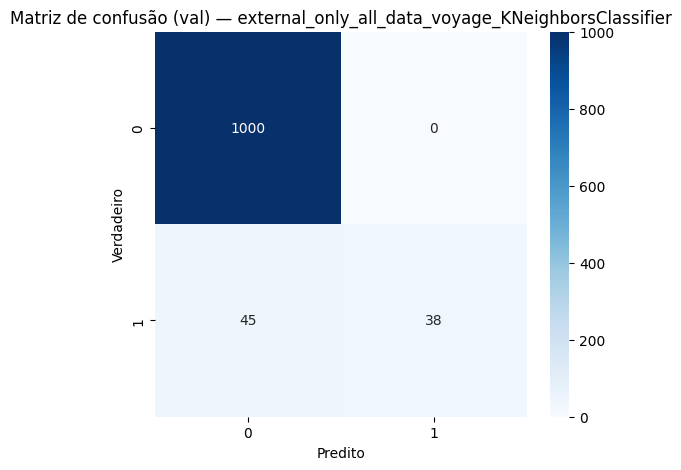

### Validando: external_only_all_data_openai_RandomForestClassifier

- Acurácia (val): **0.9714** | F1-macro (val): **0.8776** | FP: **0** | FN: **31**

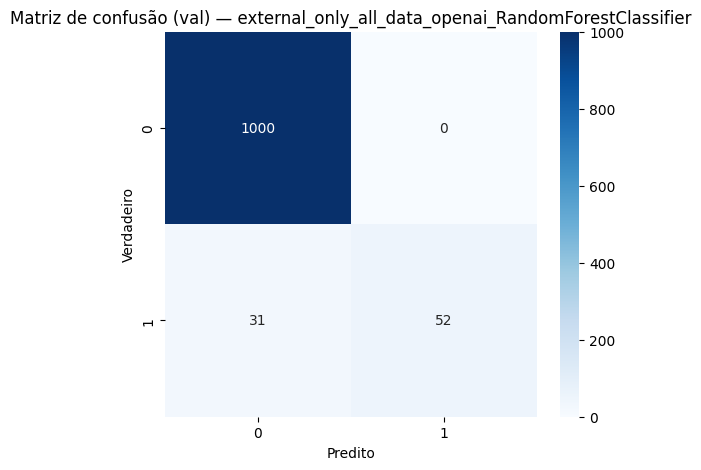

### Validando: external_only_all_data_openai_KNeighborsClassifier

- Acurácia (val): **0.9658** | F1-macro (val): **0.8475** | FP: **0** | FN: **37**

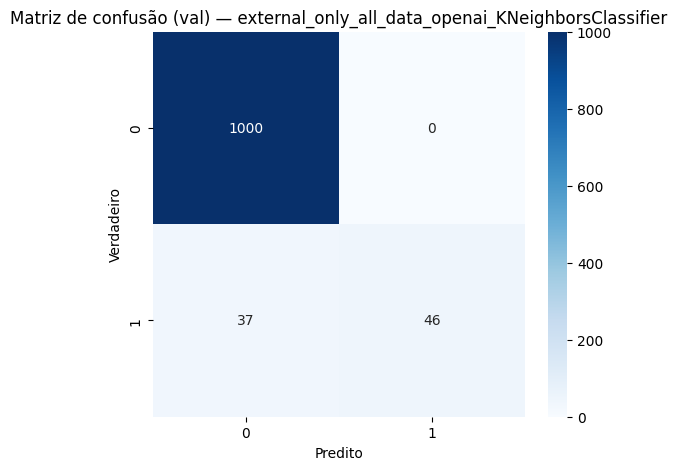

## Validação — augmented_suspect_turns (Top 5)

,label,accuracy,f1_macro,fp_total,fn_total,fp_fn_sum
43,augmented_suspect_turns_openai_SVC,0.973,0.968,24,19,43
48,augmented_suspect_turns_voyage_SVC,0.972,0.967,23,22,45
42,augmented_suspect_turns_openai_RandomForestCla...,0.963,0.955,46,14,60
45,augmented_suspect_turns_voyage_KNeighborsClass...,0.961,0.954,24,39,63
47,augmented_suspect_turns_voyage_RandomForestCla...,0.961,0.952,51,12,63


### Validando: augmented_suspect_turns_openai_SVC

- Acurácia (val): **0.9391** | F1-macro (val): **0.6540** | FP: **0** | FN: **66**

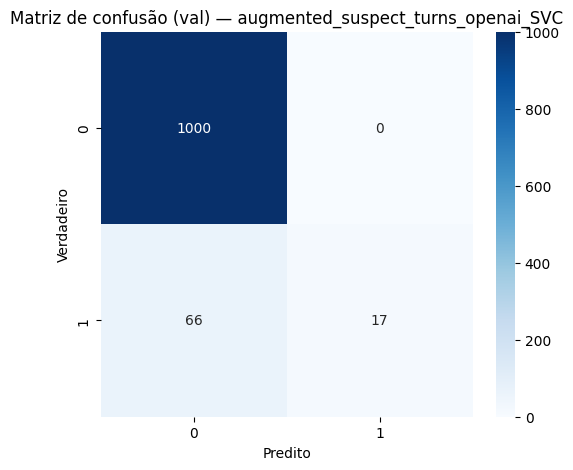

### Validando: augmented_suspect_turns_voyage_SVC

- Acurácia (val): **0.9631** | F1-macro (val): **0.8315** | FP: **0** | FN: **40**

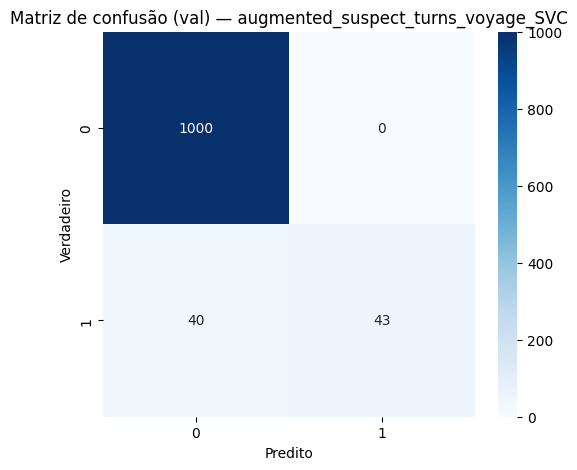

### Validando: augmented_suspect_turns_openai_RandomForestClassifier

- Acurácia (val): **0.9520** | F1-macro (val): **0.7593** | FP: **0** | FN: **52**

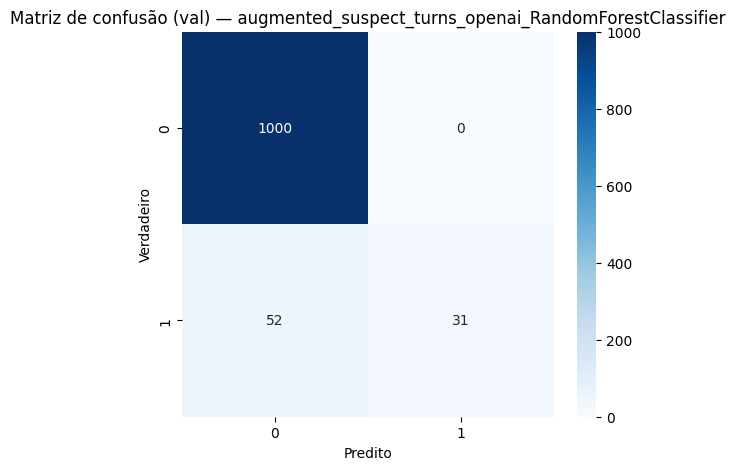

### Validando: augmented_suspect_turns_voyage_KNeighborsClassifier

- Acurácia (val): **0.9557** | F1-macro (val): **0.7849** | FP: **0** | FN: **48**

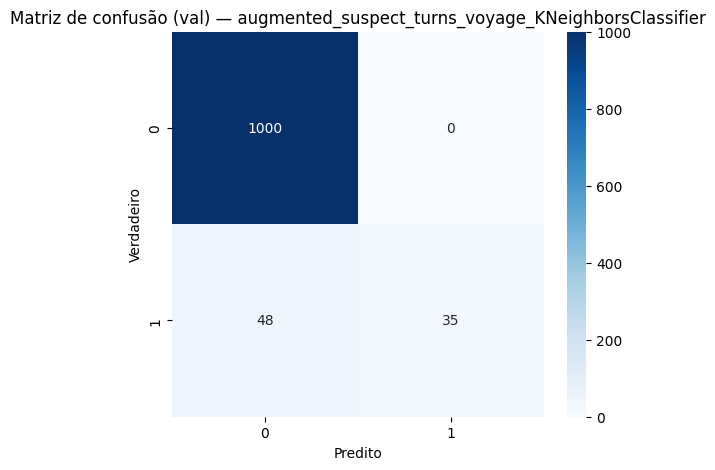

### Validando: augmented_suspect_turns_voyage_RandomForestClassifier

- Acurácia (val): **0.9631** | F1-macro (val): **0.8315** | FP: **0** | FN: **40**

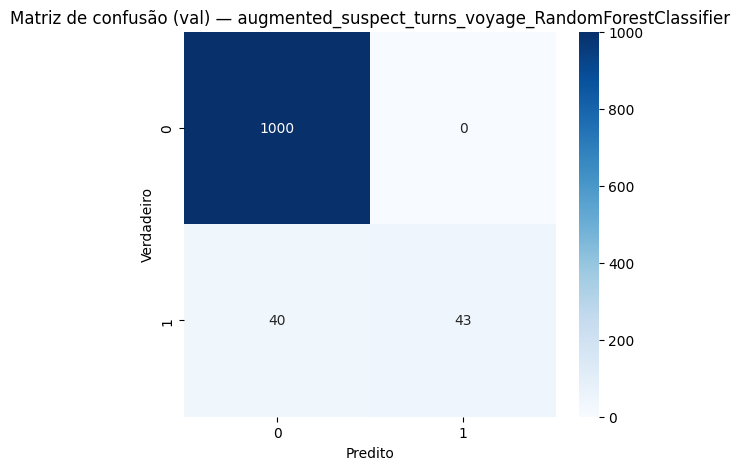

## Validação — external_only_suspect_turns (Top 5)

,label,accuracy,f1_macro,fp_total,fn_total,fp_fn_sum
98,external_only_suspect_turns_voyage_SVC,0.967,0.966,21,14,35
93,external_only_suspect_turns_openai_SVC,0.964,0.963,23,15,38
95,external_only_suspect_turns_voyage_KNeighborsC...,0.956,0.956,24,22,46
97,external_only_suspect_turns_voyage_RandomFores...,0.954,0.954,37,11,48
78,external_only_suspect_turns_bge_SVC,0.947,0.947,35,20,55


### Validando: external_only_suspect_turns_voyage_SVC

- Acurácia (val): **0.9612** | F1-macro (val): **0.8204** | FP: **0** | FN: **42**

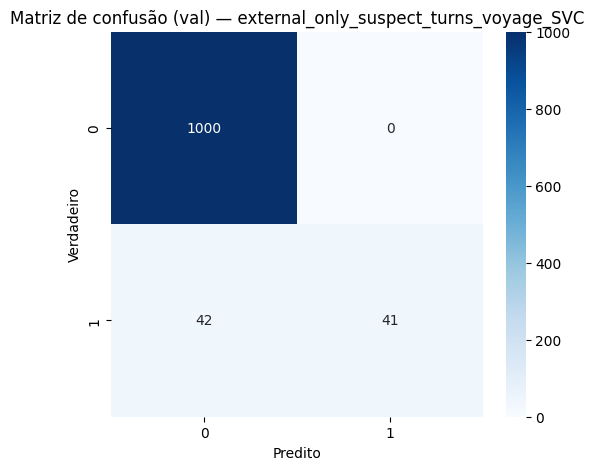

### Validando: external_only_suspect_turns_openai_SVC

- Acurácia (val): **0.9391** | F1-macro (val): **0.6540** | FP: **0** | FN: **66**

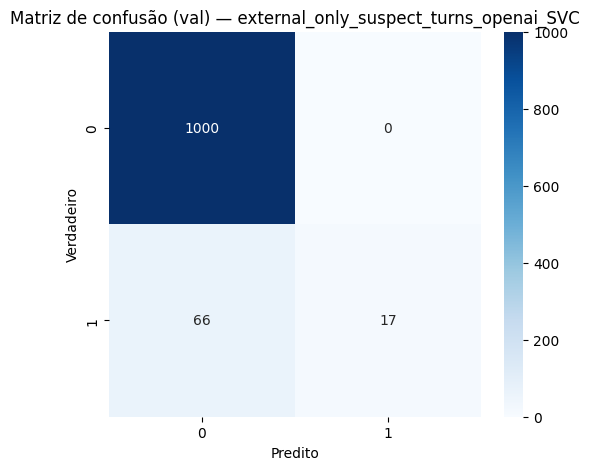

### Validando: external_only_suspect_turns_voyage_KNeighborsClassifier

- Acurácia (val): **0.9557** | F1-macro (val): **0.7849** | FP: **0** | FN: **48**

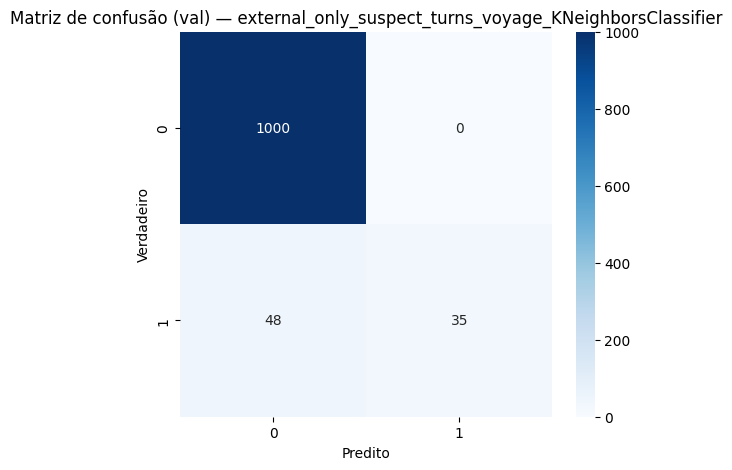

### Validando: external_only_suspect_turns_voyage_RandomForestClassifier

- Acurácia (val): **0.9529** | F1-macro (val): **0.7658** | FP: **0** | FN: **51**

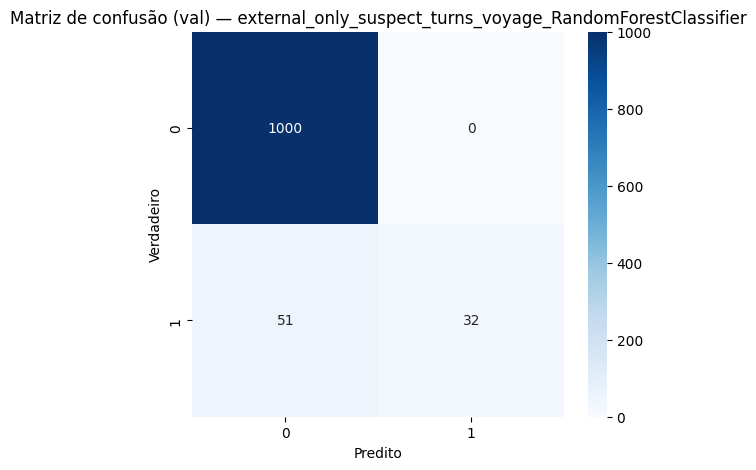

### Validando: external_only_suspect_turns_bge_SVC

- Acurácia (val): **0.9234** | F1-macro (val): **0.5030** | FP: **2** | FN: **81**

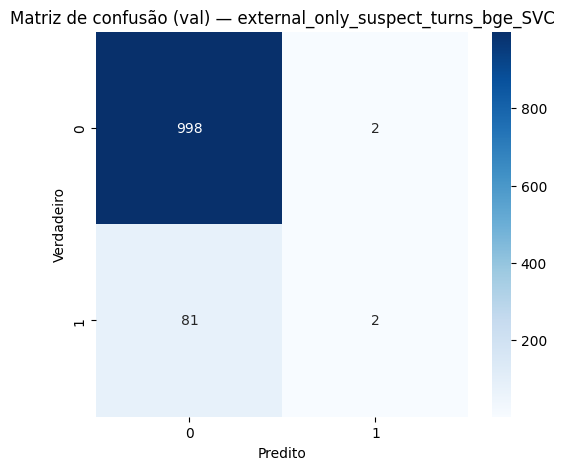


Validação do Top-5 por tipo concluída.


In [ ]:
# Célula 9: validação dos top-5 modelos selecionados usando `dataset_validation`
from IPython.display import Markdown, display
import os
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

OUT_DIR = os.path.join('..', 'machine_learning', 'visualizations')
summary_csv = os.path.join(OUT_DIR, 'models_metrics_summary.csv')
if not os.path.exists(summary_csv):
    raise FileNotFoundError(f'Resumo não encontrado em: {summary_csv}')

metrics = pd.read_csv(summary_csv)
metrics = metrics.sort_values(['train_type', 'fp_fn_sum', 'fp_total', 'fn_total'])

train_types = ['augmented_all_data', 'external_only_all_data', 'augmented_suspect_turns', 'external_only_suspect_turns']

for train_type in train_types:
    subset = metrics[metrics['train_type'] == train_type].head(5)
    if subset.empty:
        display(Markdown(f'### {train_type} — sem resultados'))
        continue

    display(Markdown(f'## Validação — {train_type} (Top 5)'))
    display(subset[['label', 'accuracy', 'f1_macro', 'fp_total', 'fn_total', 'fp_fn_sum']])

    for _, row in subset.iterrows():
        label = row['label']
        embedding = row.get('embedding')
        model_name = row.get('model_name')

        path_data = 'all_data' if 'all_data' in train_type else 'suspect_turns'
        origin = 'augmented' if train_type.startswith('augmented') else 'external_only'

        model_filename = f"{origin}_{path_data}_{embedding}_{model_name}.joblib"
        model_path = os.path.join('..', 'trained_models', model_filename)

        validation_parquet = os.path.join('..', 'datasets', 'dataset_validation', 'processed', path_data, f"{embedding}_chunks.parquet")

        display(Markdown(f"### Validando: {label}"))

        if not os.path.exists(model_path):
            display(Markdown(f"- Modelo não encontrado: {model_path} — pulando."))
            continue
        if not os.path.exists(validation_parquet):
            display(Markdown(f"- Arquivo de validação não encontrado: {validation_parquet} — pulando."))
            continue

        # Carrega parquet de validação
        try:
            df_val = pd.read_parquet(validation_parquet)
        except Exception as e:
            display(Markdown(f"- Erro ao ler parquet de validação: {e} — pulando."))
            continue

        # Identifica coluna de embeddings
        if 'text_embedded' in df_val.columns:
            X_val = list(df_val['text_embedded'])
        elif 'embedding' in df_val.columns:
            X_val = list(df_val['embedding'])
        else:
            display(Markdown(f"- Coluna de embeddings não encontrada em {validation_parquet} — pulando."))
            continue

        y_val = list(df_val['label'])

        # Carrega modelo
        try:
            model = joblib.load(model_path)
        except Exception as e:
            display(Markdown(f"- Erro ao carregar modelo: {e} — pulando."))
            continue

        try:
            y_pred = model.predict(X_val)
        except Exception as e:
            display(Markdown(f"- Erro na predição (provável incompatibilidade de embedding/dimensão): {e} — pulando."))
            continue

        try:
            acc = accuracy_score(y_val, y_pred)
            f1m = f1_score(y_val, y_pred, average='macro')
        except Exception as e:
            display(Markdown(f"- Erro ao calcular métricas: {e}"))
            continue

        cm = confusion_matrix(y_val, y_pred)
        fp = fn = None
        if cm.shape == (2,2):
            tn, fp, fn, tp = cm.ravel()
        else:
            fp = int(cm.sum() - np.trace(cm))
            fn = 0

        display(Markdown(f"- Acurácia (val): **{acc:.4f}** | F1-macro (val): **{f1m:.4f}** | FP: **{fp}** | FN: **{fn}**"))

        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Matriz de confusão (val) — {label}')
        plt.xlabel('Predito')
        plt.ylabel('Verdadeiro')
        plt.show()

print('\nValidação do Top-5 por tipo concluída.')


**Interpretação dos resultados**

Foi perceptível que o embedding que trouxe melhores resultados para nós foi o Voyage (principalmente) e o Openai e o BGE. O classificador que melhor desempenhou foi o SVC (Support Vector Classificator). Também é perceptível que os turnos da vítima são muito importantes para que possamos identificar o Scam. 

O Data Augmentation ajudou a aumentar as métrcas de treino mas não faz grandes diferenças na validação, o que mostra que as métricas estão relacionadas ao maior numero de dados que ele ja sabe classificar do que uma melhora real nos dados da vida real

**Modelos Treinados com todos os turnos, mas aplicados para turnos apenas com o Suspeito**

E se nós pudessemos treinar um modelo olhando para os turnos da vítima, mas quando fossemos colocar em produção olhássemos apenas para as mensagens do suspeiro, preservando os dados sensíveis da vítima real, funcionaria? 

Isso que essa parte do notebook visa responder, vamos ver como se saem os modelos treinados com mais dados em um cenário de menos conversas

**Com DATASET DE VALIDAÇÃO**

Avaliando como os modelos treinados apenas com all_data se comportam com o dataset de validação apenas com suspect_turns...


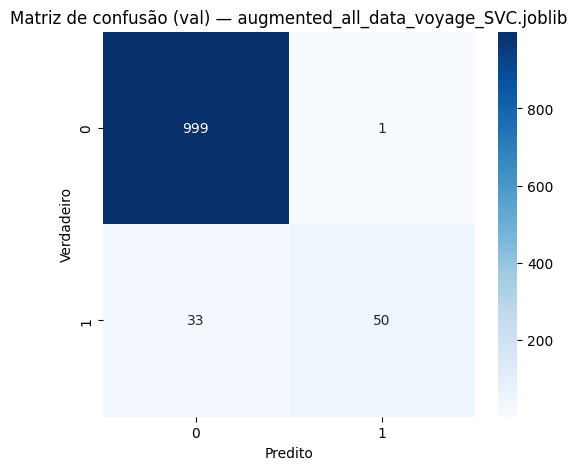

Modelo: augmented_all_data_voyage_SVC.joblib | Acurácia (val): 0.9686 | F1-macro (val): 0.8648 | FP: 1 | FN: 33


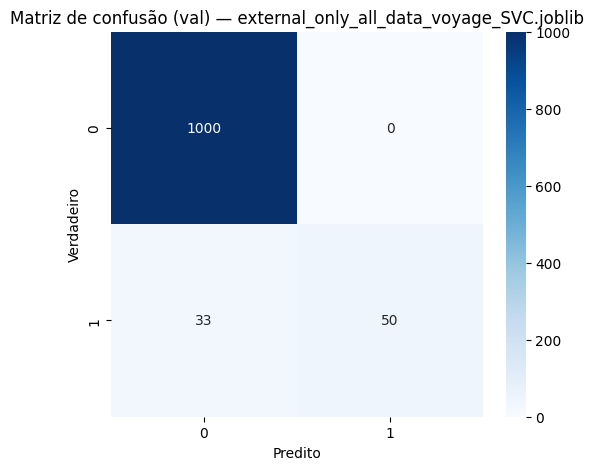

Modelo: external_only_all_data_voyage_SVC.joblib | Acurácia (val): 0.9695 | F1-macro (val): 0.8678 | FP: 0 | FN: 33


In [ ]:
print("Avaliando como os modelos treinados apenas com all_data se comportam com o dataset de validação apenas com suspect_turns...")

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

bests_models = ['augmented_all_data_voyage_SVC.joblib', 'external_only_all_data_voyage_SVC.joblib']

for model_filename in bests_models:
    model = joblib.load(os.path.join('..', 'trained_models', model_filename))

    validation_parquet = os.path.join('..', 'datasets', 'dataset_validation', 'processed', 'suspect_turns', f"voyage_chunks.parquet")
    df_val = pd.read_parquet(validation_parquet)
    X_val = list(df_val['text_embedded'])
    y_val = list(df_val['label'])
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='macro')
    cm = confusion_matrix(y_val, y_pred)
    fp = fn = None
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        fp = int(cm.sum() - np.trace(cm))
        fn = 0

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusão (val) — {model_filename}')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()
    
    print(f"Modelo: {model_filename} | Acurácia (val): {acc:.4f} | F1-macro (val): {f1m:.4f} | FP: {fp} | FN: {fn}")

**COM DATASET DE TREINO**

Testando como os modelos treinados apenas com all_data se comportam com o dataset de validação apenas com suspect_turns...


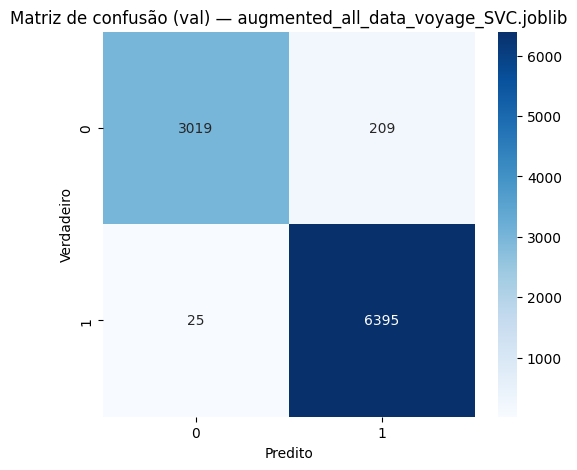

Modelo: augmented_all_data_voyage_SVC.joblib | Acurácia (val): 0.9757 | F1-macro (val): 0.9724 | FP: 209 | FN: 25


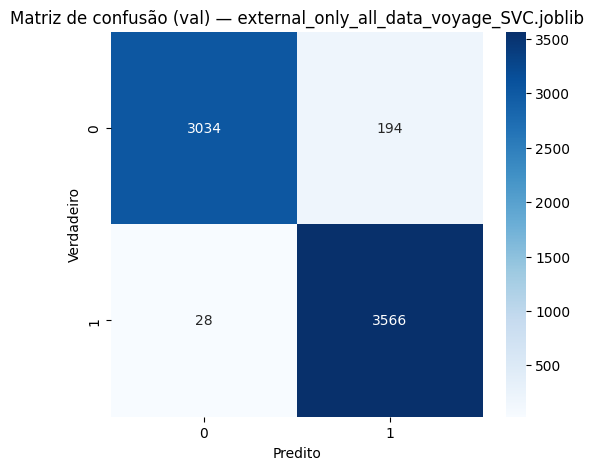

Modelo: external_only_all_data_voyage_SVC.joblib | Acurácia (val): 0.9675 | F1-macro (val): 0.9673 | FP: 194 | FN: 28


In [3]:
print("Testando como os modelos treinados apenas com all_data se comportam com o dataset de validação apenas com suspect_turns...")

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

bests_models = ['augmented_all_data_voyage_SVC.joblib', 'external_only_all_data_voyage_SVC.joblib']

for model_filename in bests_models:
    model = joblib.load(os.path.join('..', 'trained_models', model_filename))

    test_parquet = os.path.join('..', 'datasets', 'dataset_train', 'processed', 'suspect_turns', f"voyage_chunks.parquet")
    df_val = pd.read_parquet(test_parquet)

    if 'external_only' in model_filename:
        df_val = df_val[df_val['origin'] == 'external']

    X_val = list(df_val['text_embedded'])
    y_val = list(df_val['label'])
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='macro')
    cm = confusion_matrix(y_val, y_pred)
    fp = fn = None
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        fp = int(cm.sum() - np.trace(cm))
        fn = 0

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusão (val) — {model_filename}')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()
    
    print(f"Modelo: {model_filename} | Acurácia (val): {acc:.4f} | F1-macro (val): {f1m:.4f} | FP: {fp} | FN: {fn}")

## Conclusões Iniciais

Notá-se que os modelos de SVC e KNN foram disparadamente os modelos que mais desempenharam. Nesse sentido, iremos fazer alguns experimentos e estudos em cima deles para que possamos entender seu comportamento e melhorar nossos resultados de avaliação

## Estudo sobre hiper parametros do SVC

Como foi o modelo que melhor performou de forma default, vamos tentar otimiza-lo melhor ainda

In [33]:
X_train_all, X_test, y_train_all, y_test = prepare_data(path_data='all_data', embedding='voyage', train=True, with_augmented_data=True)

X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.2, random_state=42)

Carregando dados de ../datasets/dataset_train/processed/all_data/voyage_chunks.parquet...
Dados carregados. Total de amostras: 9648. 80% para treinamento, 20% para validação.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, f1_score
import tqdm

# Definição do seu espaço de hiperparâmetros
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1, 1],
    'class_weight': ['balanced', None]
}

# Transforma o dicionário em uma lista com todas as 64 combinações possíveis
grid_combinacoes = ParameterGrid(param_grid)

# Lista para armazenar o dicionário de resultados de cada experimento
resultados_experimentos = []

# O tqdm agora vai medir o progresso sobre as 64 combinações
for params in tqdm.tqdm(grid_combinacoes, desc="Avaliando combinações do Grid Search"):
    
    # Inicializa o modelo desempacotando os parâmetros atuais do dicionário
    clf = SVC(**params, random_state=42)
    clf.fit(X_train, y_train)
    
    # Obtém as funções de decisão (necessárias para a Hinge Loss)
    train_decision = clf.decision_function(X_train)
    val_decision = clf.decision_function(X_val)
    
    # Previsões discretas
    y_pred_train = clf.predict(X_train)
    y_pred_val = clf.predict(X_val)
    t_acc = accuracy_score(y_train, y_pred_train)
    v_acc = accuracy_score(y_val, y_pred_val)
    
    t_f1 = f1_score(y_train, y_pred_train, average='macro')
    v_f1 = f1_score(y_val, y_pred_val, average='macro')
    
    # Salva os parâmetros junto com os resultados obtidos
    dados_rodada = params.copy()
    dados_rodada.update({
        'train_acc': t_acc, 'val_acc': v_acc,
        'train_f1': t_f1, 'val_f1': v_f1
    })
    
    resultados_experimentos.append(dados_rodada)

# Transforma a lista de resultados em um DataFrame do Pandas para facilitar manipulação
df_resultados = pd.DataFrame(resultados_experimentos)

# ORDENAÇÃO CRUCIAL: Ordena do pior F1 de Validação para o melhor F1 de Validação
df_resultados = df_resultados.sort_values(by='val_f1', ascending=True).reset_index(drop=True)

print("Grid Search finalizado!")

Avaliando combinações do Grid Search: 100%|██████████| 64/64 [13:00<00:00, 12.20s/it]

Grid Search finalizado!


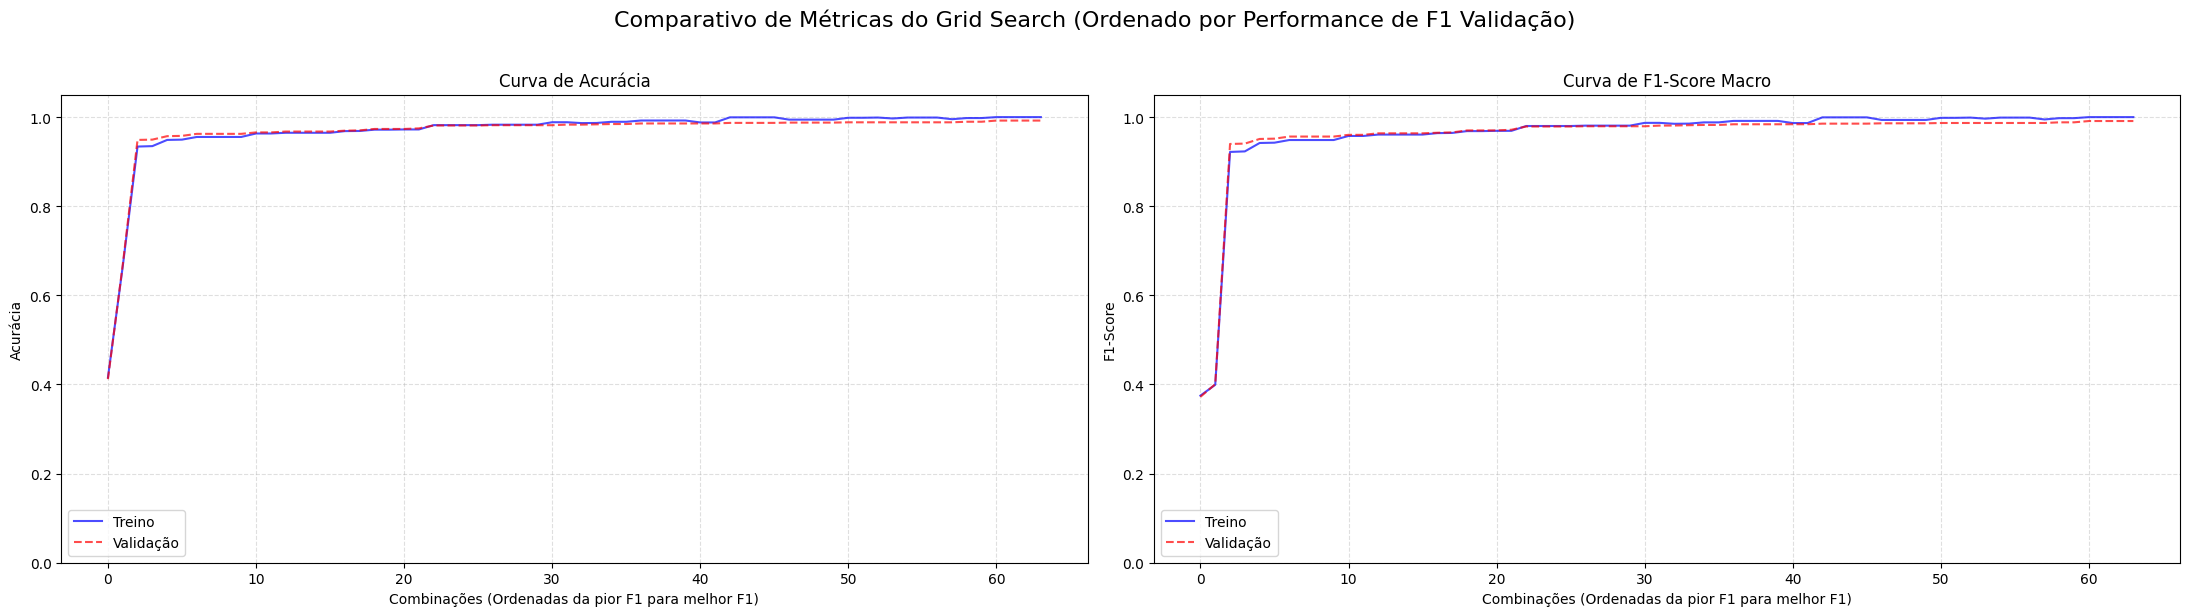

Melhor resultado encontrado:
C                  100.0
class_weight         NaN
gamma                  1
kernel               rbf
train_acc            1.0
val_acc         0.992228
train_f1             1.0
val_f1          0.991216
Name: 63, dtype: object


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6))
fig.suptitle("Comparativo de Métricas do Grid Search (Ordenado por Performance de F1 Validação)", fontsize=16, y=1.02)

# Eixo X será simplesmente o índice de 0 a 63 das combinações ordenadas
x_axis = df_resultados.index

# --- GRÁFICO 2: ACURÁCIA ---
axes[0].plot(x_axis, df_resultados['train_acc'], 'b-', label='Treino', alpha=0.7)
axes[0].plot(x_axis, df_resultados['val_acc'], 'r--', label='Validação', alpha=0.7)
axes[0].set_title('Curva de Acurácia')
axes[0].set_xlabel('Combinações (Ordenadas da pior F1 para melhor F1)')
axes[0].set_ylabel('Acurácia')
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

# --- GRÁFICO 3: F1-SCORE MACRO ---
axes[1].plot(x_axis, df_resultados['train_f1'], 'b-', label='Treino', alpha=0.7)
axes[1].plot(x_axis, df_resultados['val_f1'], 'r--', label='Validação', alpha=0.7)
axes[1].set_title('Curva de F1-Score Macro')
axes[1].set_xlabel('Combinações (Ordenadas da pior F1 para melhor F1)')
axes[1].set_ylabel('F1-Score')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Melhor resultado encontrado:")
print(df_resultados.iloc[-1])

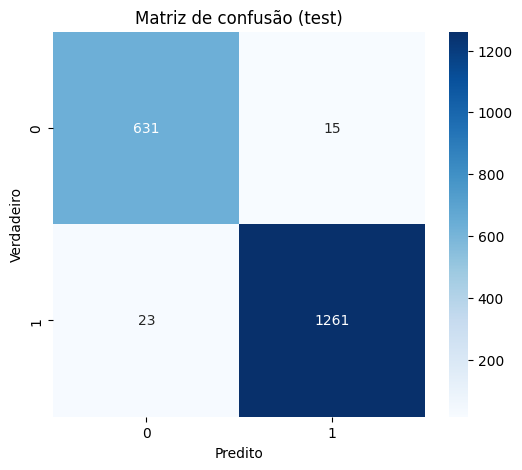

Modelo final treinado com os melhores hiperparâmetros: {'C': 100.0, 'kernel': 'rbf', 'gamma': 1}
Acurácia no conjunto de teste: 0.9803
F1-macro no conjunto de teste: 0.9780


In [51]:
from sklearn.metrics import confusion_matrix

# Treinar o modelo final com os melhores hiperparâmetros encontrados

model = SVC(**df_resultados.iloc[-1][['C', 'kernel', 'gamma']].to_dict(), random_state=42)
model.fit(X_train, y_train)

# Confusion matrix para o conjunto de teste
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de confusão (test)')
plt.xlabel('Predito')
plt.ylabel('Verdadeiro')
plt.show()

print(f"Modelo final treinado com os melhores hiperparâmetros: {df_resultados.iloc[-1][['C', 'kernel', 'gamma']].to_dict()}")
print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-macro no conjunto de teste: {f1_score(y_test, y_pred, average='macro'):.4f}")

In [63]:
def validate_real_dataset(model):
    validation_parquet = os.path.join('..', 'datasets', 'dataset_validation', 'processed', 'all_data', f"voyage_chunks.parquet")
    df_real = pd.read_parquet(validation_parquet)
    X_real = list(df_real['text_embedded'])
    y_real = list(df_real['label'])

    y_pred = model.predict(X_real)
    acc = accuracy_score(y_real, y_pred)
    f1m = f1_score(y_real, y_pred, average='macro')
    cm = confusion_matrix(y_real, y_pred)
    fp = fn = None
    if cm.shape == (2,2):
        tn, fp, fn, tp = cm.ravel()
    else:
        fp = int(cm.sum() - np.trace(cm))
        fn = 0

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de confusão (val)')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    print(f"Matriz de Confusão (val) | Acurácia: {acc:.4f} | F1-macro: {f1m:.4f} | FP: {fp} | FN: {fn}")

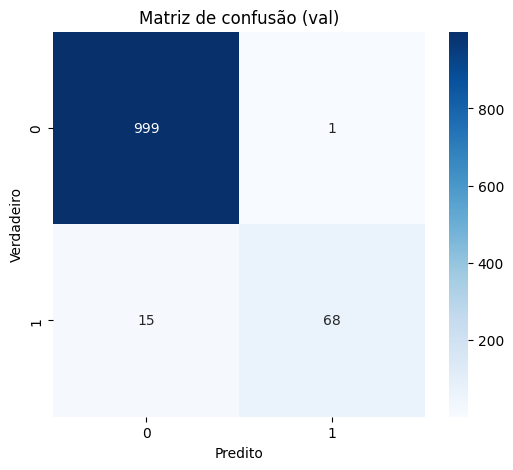

Matriz de Confusão (val) | Acurácia: 0.9852 | F1-macro: 0.9434 | FP: 1 | FN: 15


In [64]:
validate_real_dataset(model)

## Alterando Trash-Hold

Vamos alterar o trash-hold do SVC para que possamos zerar o numero de falsos negativos no treino. Vamos ver como isso influencia no dataset de validação

**Modelo Otimizado**

In [76]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
def evaluate_model_with_custom_threshold(model, X_test, y_test):
    y_test_limpo = np.array(y_test).ravel()

    y_scores = model.decision_function(X_test)

    threshold_para_zerar_fn = np.min(y_scores[y_test_limpo == 1]) - 0.001

    print(f"Threshold original do SVM: 0.0")
    print(f"Novo threshold aplicado: {threshold_para_zerar_fn:.4f}\n")

    # 3. Aplicar o novo threshold para gerar as novas predições
    y_pred_novo = (y_scores >= threshold_para_zerar_fn).astype(int)

    # 4. Calcular e plotar a nova Confusion Matrix
    cm_nova = confusion_matrix(y_test, y_pred_novo)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_nova, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão (Threshold Customizado)')
    plt.xlabel('Predito')
    plt.ylabel('Verdadeiro')
    plt.show()

    # 5. Avaliar o impacto nas métricas
    print(f"Modelo final treinado com os melhores hiperparâmetros: {df_resultados.iloc[-1][['C', 'kernel', 'gamma']].to_dict()}")
    print(f"Acurácia no conjunto de teste: {accuracy_score(y_test, y_pred_novo):.4f}")
    print(f"F1-macro no conjunto de teste: {f1_score(y_test, y_pred_novo, average='macro'):.4f}")

Threshold original do SVM: 0.0
Novo threshold aplicado: -1.5261



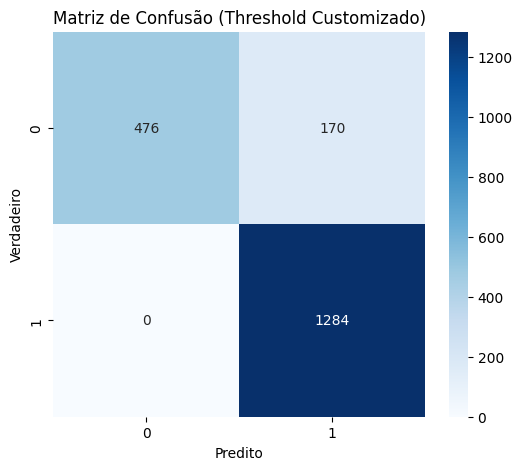

Modelo final treinado com os melhores hiperparâmetros: {'C': 100.0, 'kernel': 'rbf', 'gamma': 1}
Acurácia no conjunto de teste: 0.9119
F1-macro no conjunto de teste: 0.8932


In [77]:
model_zero_FN = SVC(**df_resultados.iloc[-1][['C', 'kernel', 'gamma']].to_dict(), random_state=42)
model_zero_FN.fit(X_train_all, y_train_all)
evaluate_model_with_custom_threshold(model_zero_FN, X_test, y_test)

{'C': 100.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 1, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}


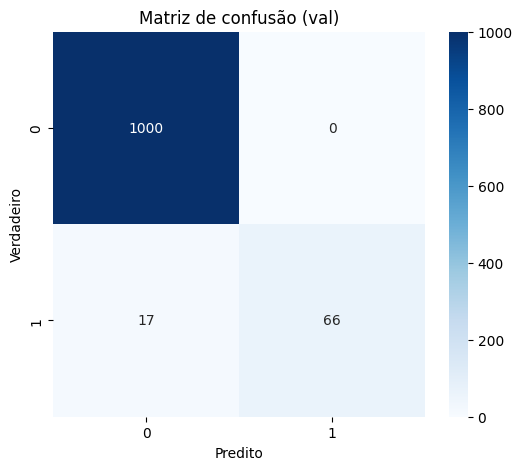

Matriz de Confusão (val) | Acurácia: 0.9843 | F1-macro: 0.9387 | FP: 0 | FN: 17


In [78]:
print(model_zero_FN.get_params())

validate_real_dataset(model_zero_FN)

**Modelo Default**

Aviso: length_data não fornecido para RF. Usando n_estimators=100 por padrão.
Aviso: length_data não fornecido para XGBOOST. Usando n_estimators=100 por padrão.
Threshold original do SVM: 0.0
Novo threshold aplicado: -1.0441



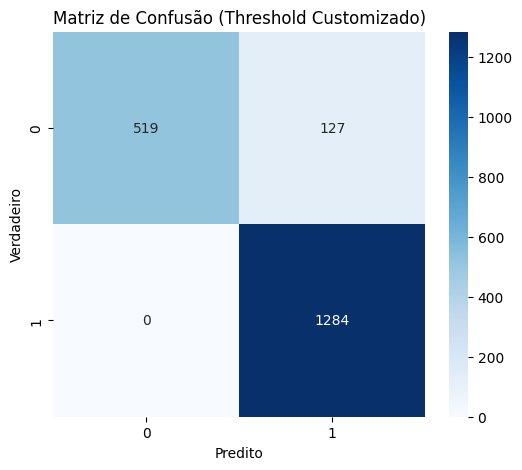

Modelo final treinado com os melhores hiperparâmetros: {'C': 100.0, 'kernel': 'rbf', 'gamma': 1}
Acurácia no conjunto de teste: 0.9342
F1-macro no conjunto de teste: 0.9219


In [79]:
model_default = get_all_classifiers()["SVM"]
model_default.fit(X_train_all, y_train_all)
evaluate_model_with_custom_threshold(model_default, X_test, y_test)

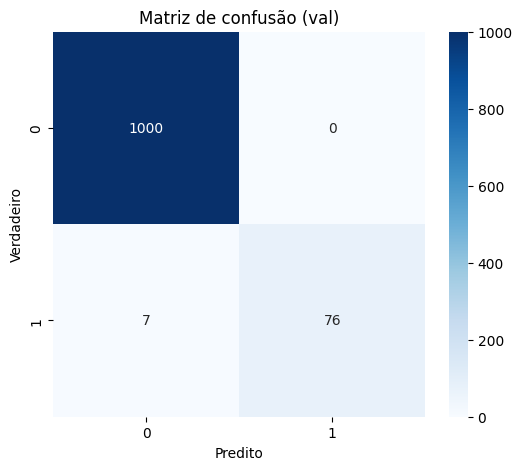

Matriz de Confusão (val) | Acurácia: 0.9935 | F1-macro: 0.9762 | FP: 0 | FN: 7


In [80]:
validate_real_dataset(model_default)

## Avaliação do tamanho do dataset

Para sabermos quanto de dado é realmente necessário para o modelo, vamos analizar a curva de aprendizado para um dataset de 10%, 25%, 50%, 75% e 100% do dataset base.

Processando: all_data | voyage | SVC | accuracy
Processando: all_data | voyage | SVC | f1_macro
Processando: all_data | voyage | KNN | accuracy
Processando: all_data | voyage | KNN | f1_macro
Processando: all_data | openai | SVC | accuracy
Processando: all_data | openai | SVC | f1_macro
Processando: all_data | openai | KNN | accuracy
Processando: all_data | openai | KNN | f1_macro
Processando: suspect_turns | voyage | SVC | accuracy
Processando: suspect_turns | voyage | SVC | f1_macro
Processando: suspect_turns | voyage | KNN | accuracy
Processando: suspect_turns | voyage | KNN | f1_macro
Processando: suspect_turns | openai | SVC | accuracy
Processando: suspect_turns | openai | SVC | f1_macro
Processando: suspect_turns | openai | KNN | accuracy
Processando: suspect_turns | openai | KNN | f1_macro


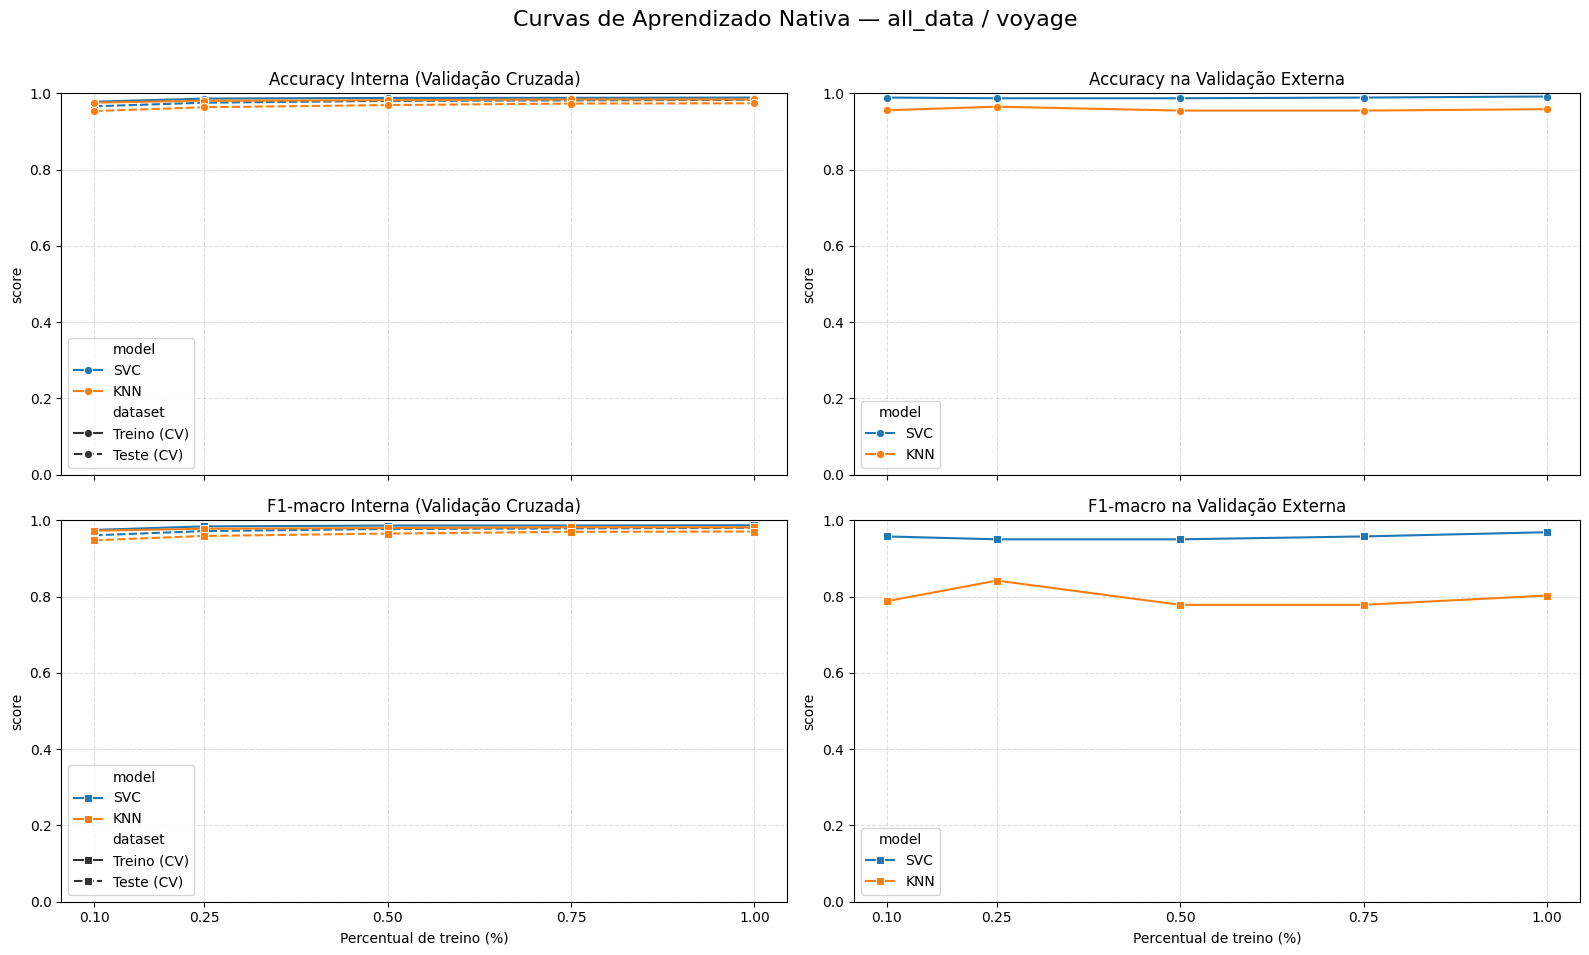

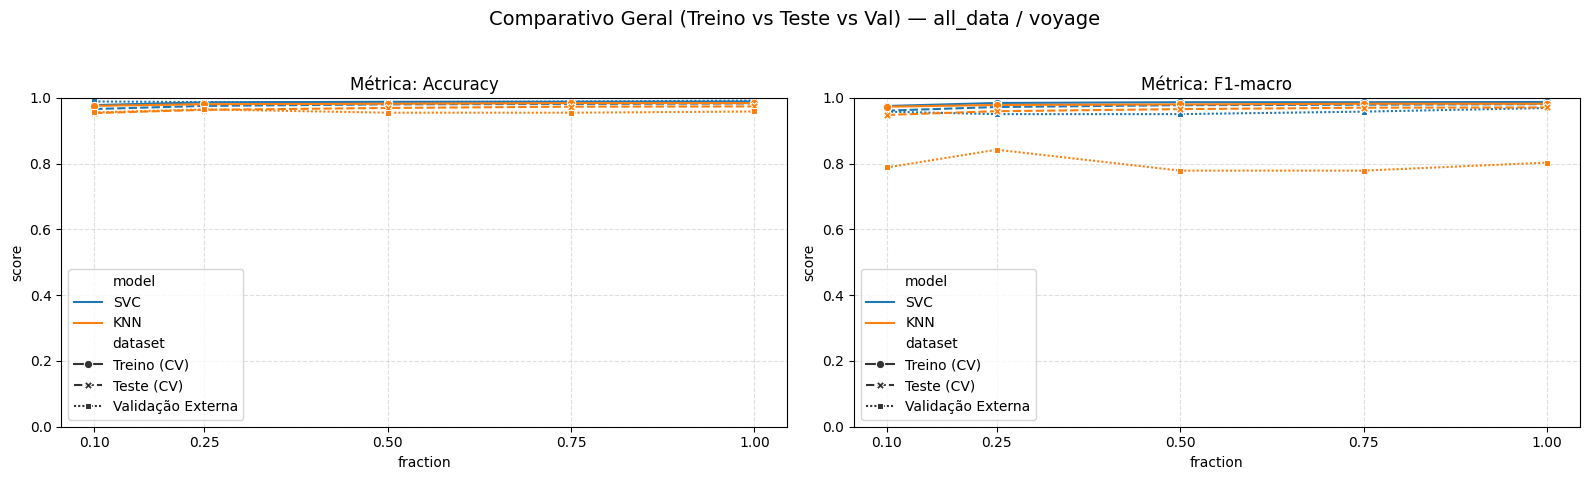

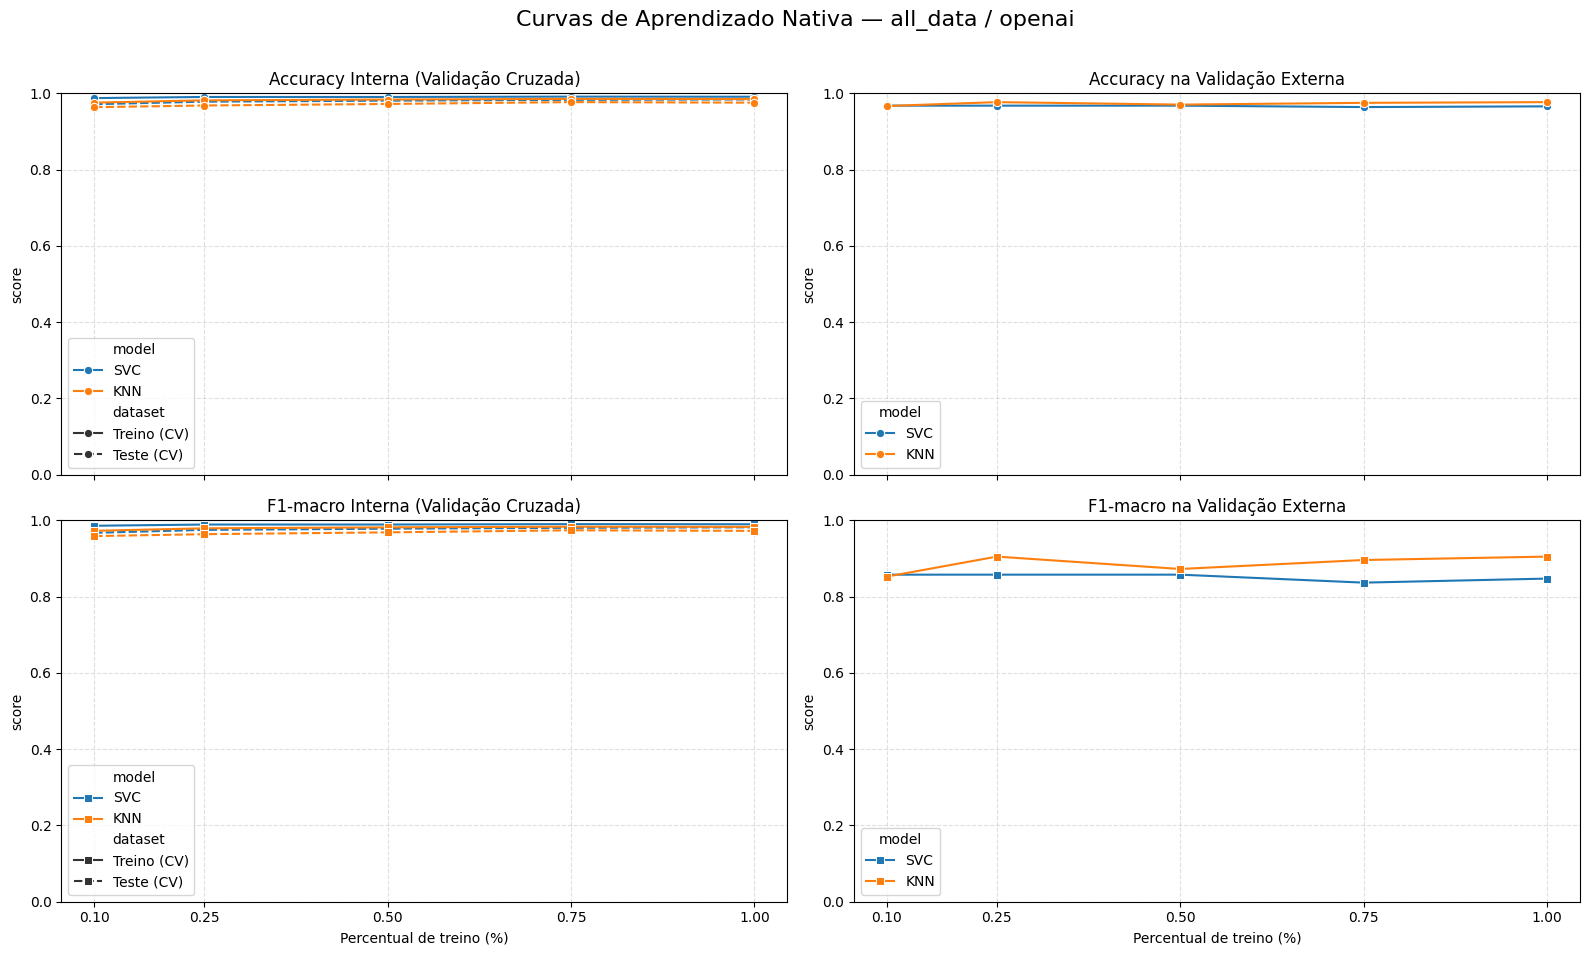

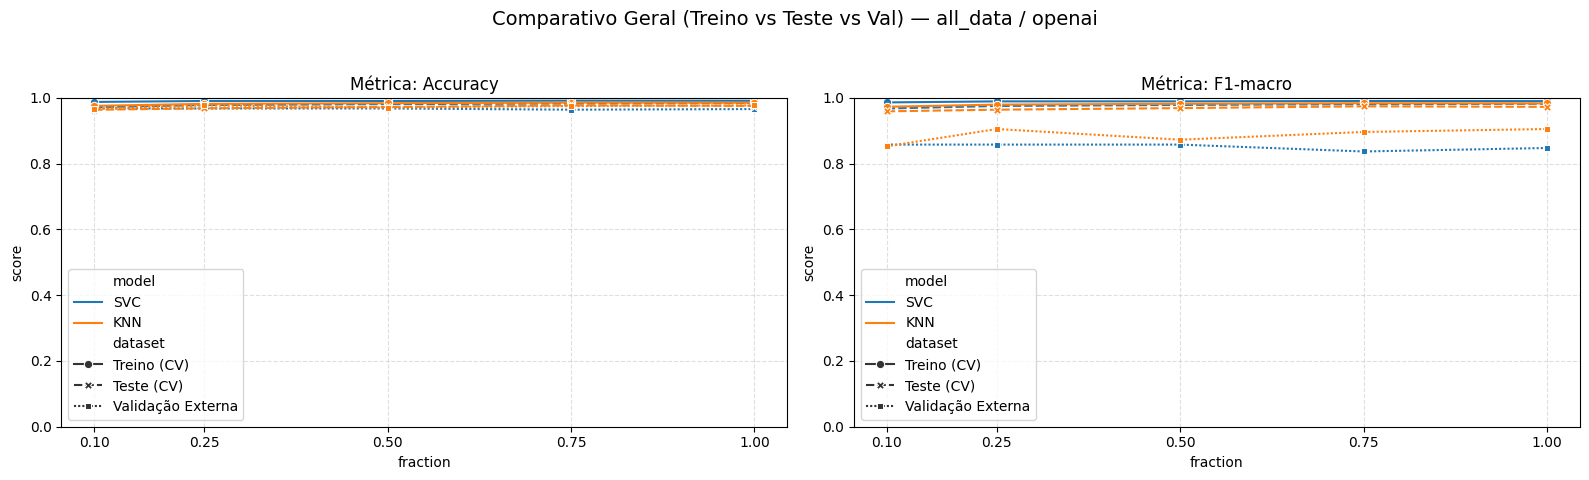

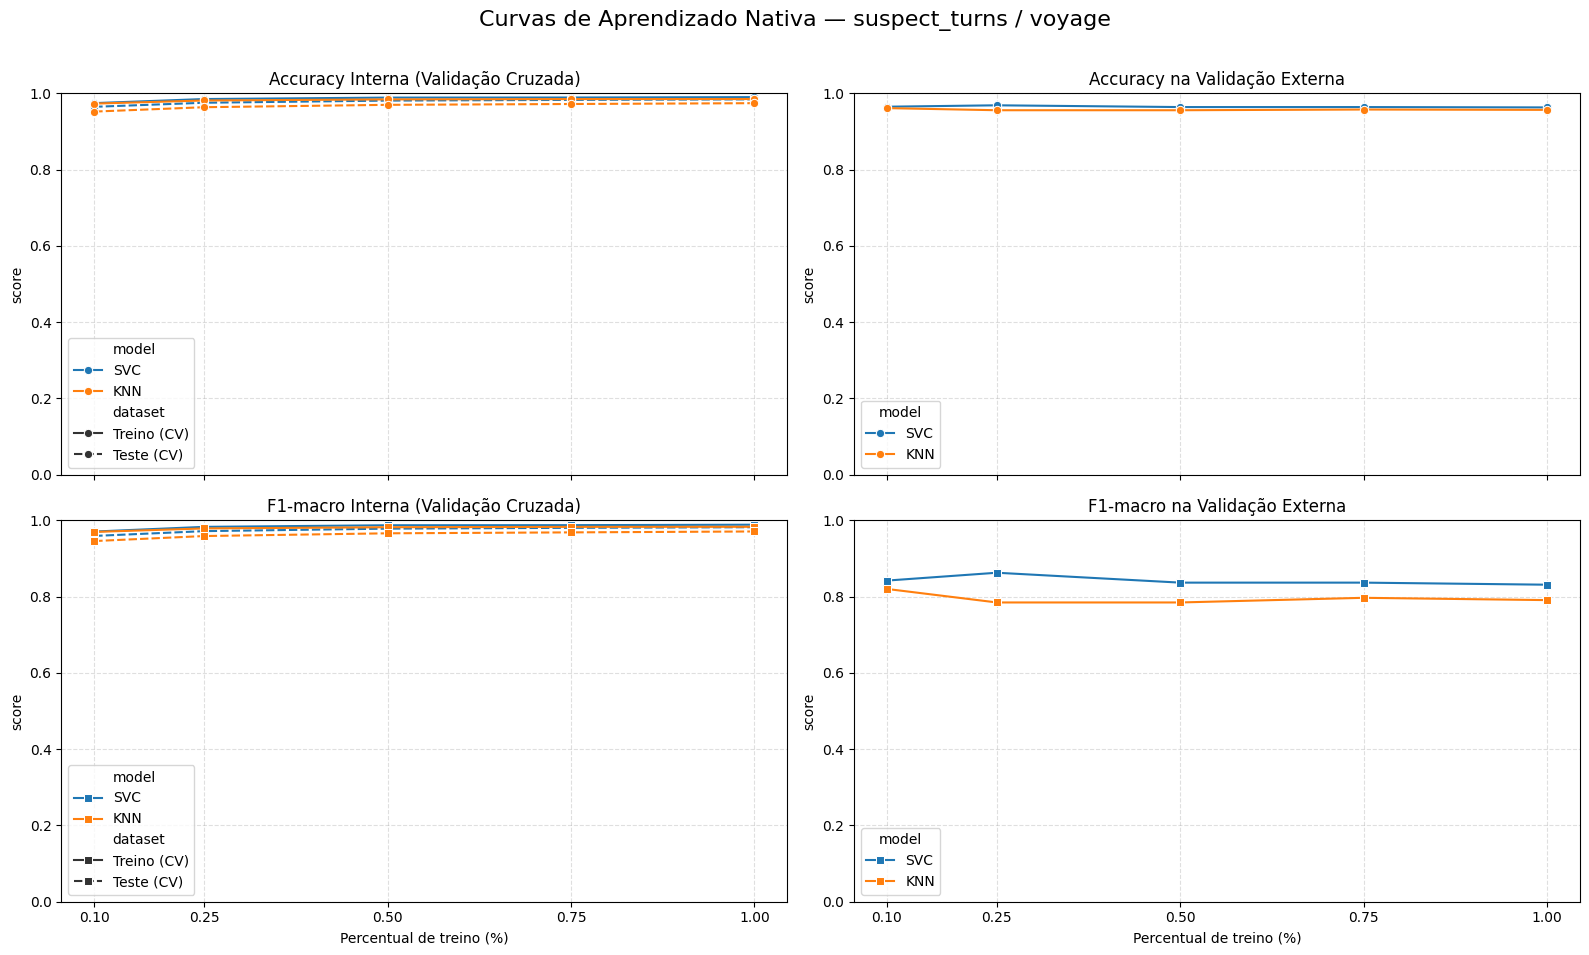

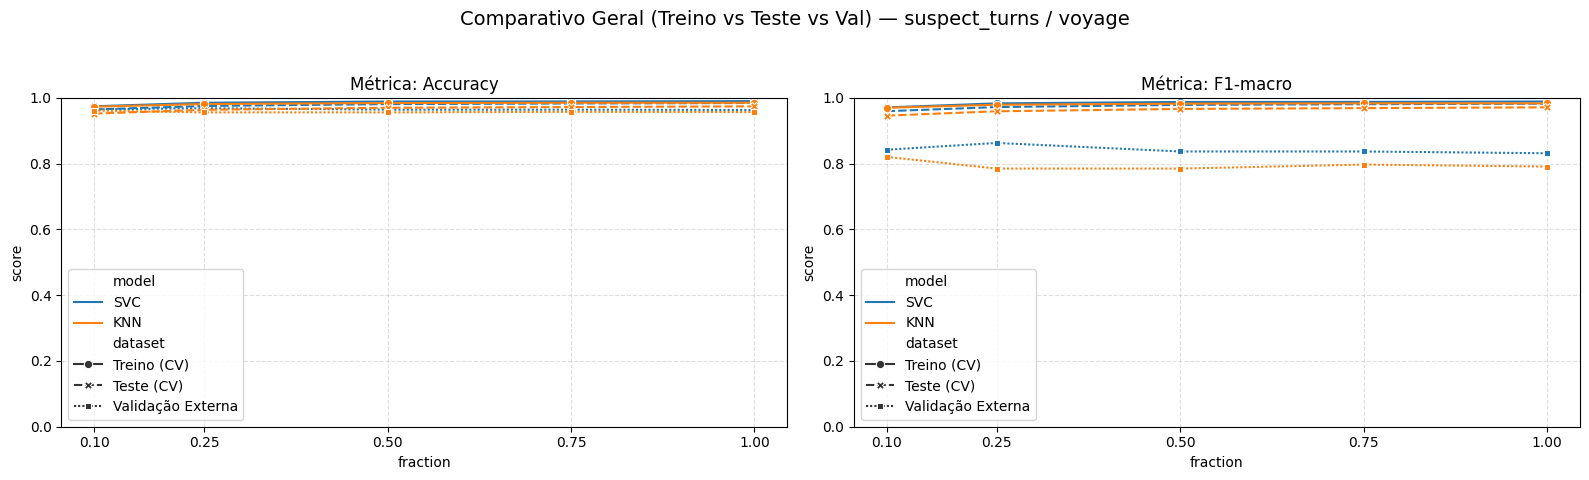

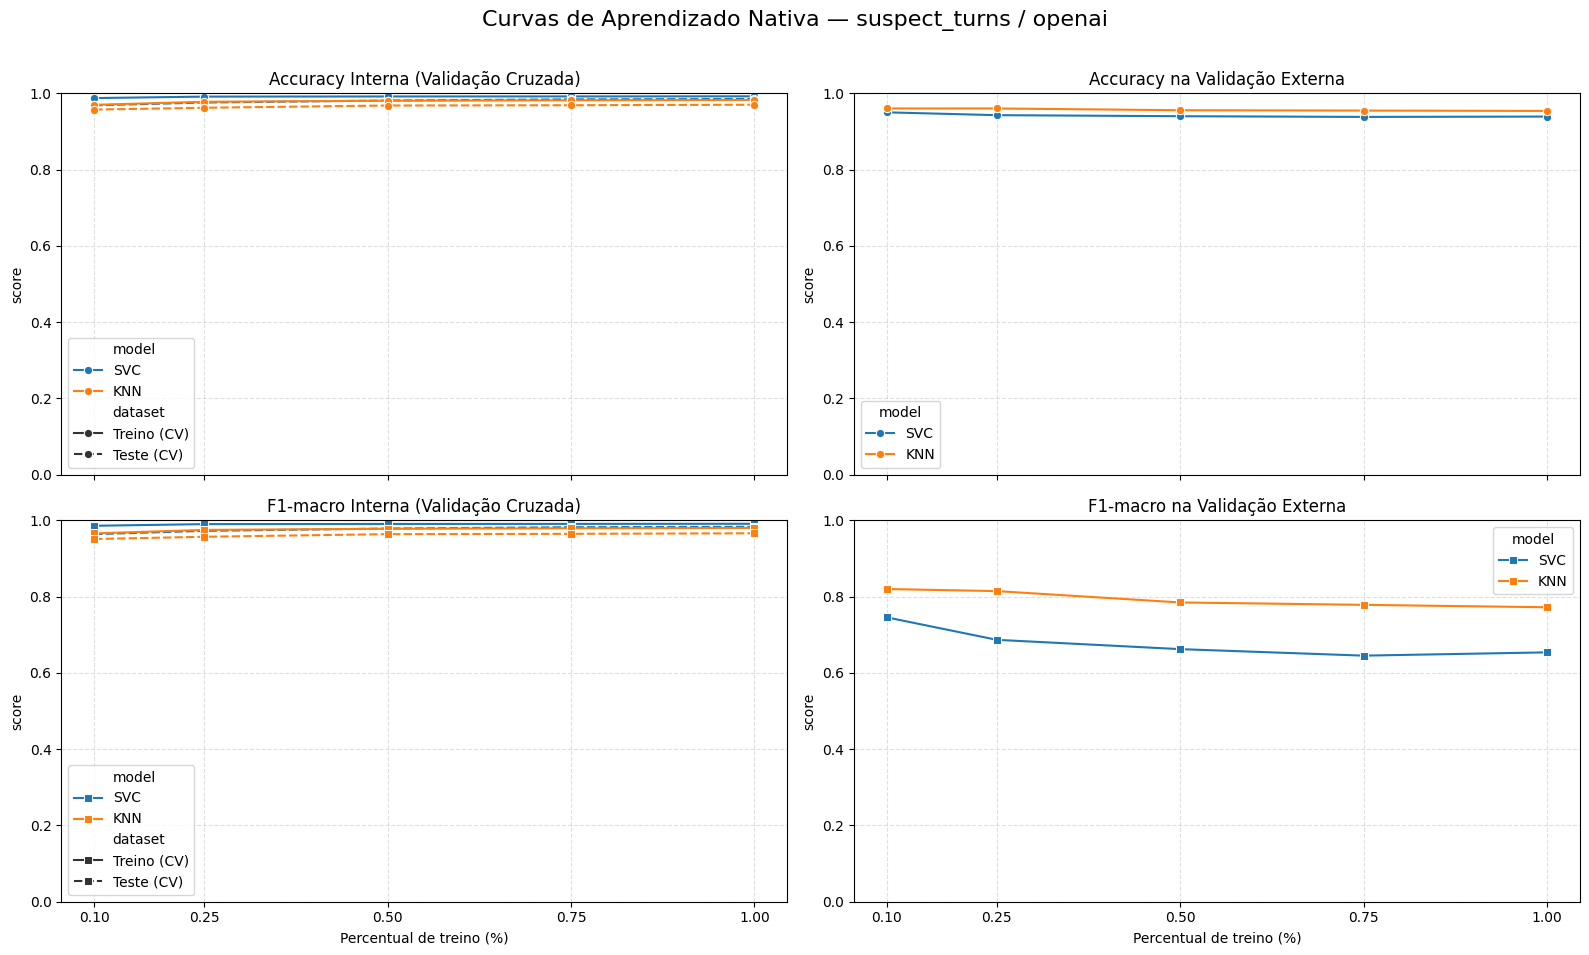

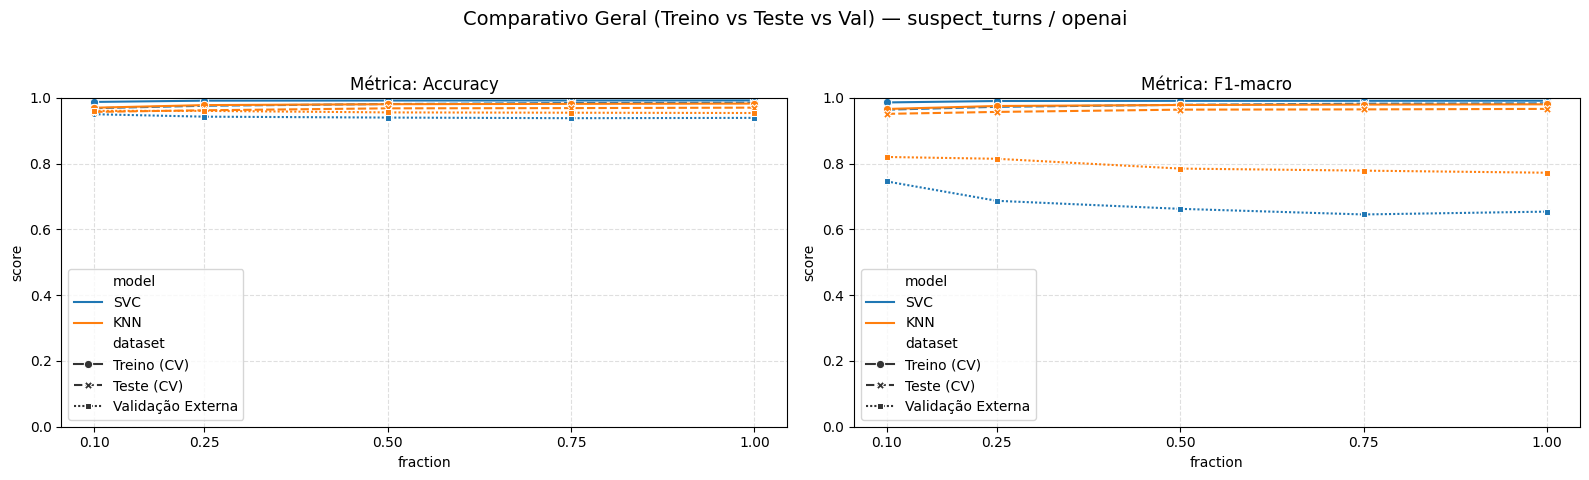

In [82]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone
from sklearn.model_selection import learning_curve, StratifiedKFold, PredefinedSplit

learning_percentages = [0.1, 0.25, 0.5, 0.75, 1.0]
selected_models = {
    'SVC': SVC(kernel='rbf', probability=False, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = []
path_datas = ['all_data', 'suspect_turns']

for path_data in path_datas:
    for emb_name in EMBEDDERS.keys():
        parquet_file = f"../datasets/dataset_train/processed/{path_data}/{emb_name}_chunks.parquet"
        if not os.path.exists(parquet_file):
            print(f"Arquivo não encontrado: {parquet_file}. Pulando.")
            continue

        df = pd.read_parquet(parquet_file)
        if df.empty:
            continue

        # Preparação dos dados de Treino
        X = np.stack(df['text_embedded'].values).astype(np.float32)
        y = np.array(df['label'])

        # Carrega o Dataset de Validação Externa (se existir)
        validation_parquet = f"../datasets/dataset_validation/processed/{path_data}/{emb_name}_chunks.parquet"
        df_val = pd.read_parquet(validation_parquet) if os.path.exists(validation_parquet) else None
        
        X_val, y_val = None, None
        if df_val is not None and not df_val.empty:
            X_val = np.stack(df_val['text_embedded'].values).astype(np.float32)
            y_val = np.array(df_val['label'])

        # Loop de Modelos e Métricas
        for model_name, model in selected_models.items():
            for metric in ['accuracy', 'f1_macro']:
                print(f"Processando: {path_data} | {emb_name} | {model_name} | {metric}")
                
                # 1. CURVA INTERNA: Usando 5-Fold Cross Validation no dataset de treino
                cv_interno = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
                
                train_sizes, train_scores, test_scores = learning_curve(
                    clone(model), X, y,
                    train_sizes=learning_percentages,
                    cv=cv_interno,
                    scoring=metric,
                    shuffle=True,
                    random_state=42,
                    n_jobs=-1
                )
                
                # Extrai a média dos 5 folds para cada fração de treino
                mean_train = np.mean(train_scores, axis=1)
                mean_test = np.mean(test_scores, axis=1)
                
                for pct, tr_sc, te_sc in zip(learning_percentages, mean_train, mean_test):
                    results.append({'path_data': path_data, 'embedding': emb_name, 'model': model_name, 'fraction': pct, 'metric': metric, 'dataset': 'Treino (CV)', 'score': tr_sc})
                    results.append({'path_data': path_data, 'embedding': emb_name, 'model': model_name, 'fraction': pct, 'metric': metric, 'dataset': 'Teste (CV)', 'score': te_sc})

                # 2. CURVA EXTERNA: Avaliação no dataset de validação estático
                if X_val is not None:
                    # Combinamos treino e validação para o learning_curve separar internamente
                    X_combined = np.vstack([X, X_val])
                    y_combined = np.concatenate([y, y_val])
                    
                    # Marcamos -1 para dados que variam no treino e 0 para a validação estática
                    test_fold = np.concatenate([np.full(len(X), -1), np.full(len(X_val), 0)])
                    cv_externo = PredefinedSplit(test_fold)
                    
                    _, _, val_scores = learning_curve(
                        clone(model), X_combined, y_combined,
                        train_sizes=learning_percentages,
                        cv=cv_externo,
                        scoring=metric,
                        shuffle=True,
                        random_state=42,
                        n_jobs=-1
                    )
                    
                    mean_val = np.mean(val_scores, axis=1)
                    for pct, v_sc in zip(learning_percentages, mean_val):
                        results.append({'path_data': path_data, 'embedding': emb_name, 'model': model_name, 'fraction': pct, 'metric': metric, 'dataset': 'Validação Externa', 'score': v_sc})

results_df = pd.DataFrame(results)

# --- SEÇÃO DE GRÁFICOS ---
for path_data in path_datas:
    for emb_name in results_df[results_df['path_data'] == path_data]['embedding'].unique():
        subset = results_df[(results_df['path_data'] == path_data) & (results_df['embedding'] == emb_name)]
        if subset.empty:
            continue

        # Gráfico 1: Painel 2x2 (Métricas separadas por Origem)
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
        fig.suptitle(f'Curvas de Aprendizado Nativa — {path_data} / {emb_name}', fontsize=16)

        # Top-Left: Accuracy Interna (Treino vs Teste CV)
        sns.lineplot(data=subset[(subset['metric'] == 'accuracy') & (subset['dataset'].isin(['Treino (CV)', 'Teste (CV)']))], 
                     x='fraction', y='score', hue='model', style='dataset', marker='o', ax=axes[0, 0])
        axes[0, 0].set_title('Accuracy Interna (Validação Cruzada)')

        # Top-Right: Accuracy Externa
        sns.lineplot(data=subset[(subset['metric'] == 'accuracy') & (subset['dataset'] == 'Validação Externa')], 
                     x='fraction', y='score', hue='model', marker='o', ax=axes[0, 1])
        axes[0, 1].set_title('Accuracy na Validação Externa')

        # Bottom-Left: F1 Interna
        sns.lineplot(data=subset[(subset['metric'] == 'f1_macro') & (subset['dataset'].isin(['Treino (CV)', 'Teste (CV)']))], 
                     x='fraction', y='score', hue='model', style='dataset', marker='s', ax=axes[1, 0])
        axes[1, 0].set_title('F1-macro Interna (Validação Cruzada)')

        # Bottom-Right: F1 Externa
        sns.lineplot(data=subset[(subset['metric'] == 'f1_macro') & (subset['dataset'] == 'Validação Externa')], 
                     x='fraction', y='score', hue='model', marker='s', ax=axes[1, 1])
        axes[1, 1].set_title('F1-macro na Validação Externa')

        for ax in axes.flat:
            ax.set_ylim(0, 1)
            ax.set_xticks(learning_percentages)
            ax.set_xlabel('Percentual de treino (%)')
            ax.grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # Gráfico 2: Comparativo Direto (Unificado por Métrica)
        fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
        fig2.suptitle(f'Comparativo Geral (Treino vs Teste vs Val) — {path_data} / {emb_name}', fontsize=14)

        sns.lineplot(data=subset[subset['metric'] == 'accuracy'], x='fraction', y='score', hue='model', style='dataset', markers=True, ax=axes2[0])
        axes2[0].set_title('Métrica: Accuracy')
        
        sns.lineplot(data=subset[subset['metric'] == 'f1_macro'], x='fraction', y='score', hue='model', style='dataset', markers=True, ax=axes2[1])
        axes2[1].set_title('Métrica: F1-macro')

        for ax in axes2:
            ax.set_ylim(0, 1)
            ax.set_xticks(learning_percentages)
            ax.grid(True, linestyle='--', alpha=0.4)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()